# Bottleneck Analysis: High-Concurrency Throughput Drop

Diagnose why throughput drops ~25% beyond ~1000 concurrency/decode GPU.

**Deployment**: DeepSeek-R1 NVFP4, 8 decode pods (EP32, DeepEP LL + MNNVL), 2 prefill pods (EP8, DeepEP HT), NIXL KV over UCX/IB.

**Key facts**:
- `MAX_TOKENS=1024` per decode rank (8x the DeepEP LL design point of ~128 tok/batch)
- Same drop with `uniform_random` routing -- not expert imbalance
- KV cache far from full -- not memory pressure

In [83]:
%load_ext autoreload
%autoreload 2

from eplb_analysis import (
    load_run,
    list_runs,
    filter_runs,
    stage_metrics_table,
    plot_latency_comparison,
    plot_throughput_comparison,
    plot_throughput_timeseries,
    plot_throughput_vs_concurrency,
    plot_kv_cache_usage,
    plot_latency_timeseries,
    plot_phase_time_comparison,
    plot_per_rank_latency_heatmap,
    plot_per_rank_latency_spread,
    plot_per_rank_comparison,
    per_rank_stats_table,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 40)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data + Deployment Summary

In [84]:
results_dir = "./very_high_load_new/"

print("Available runs:")
for name in list_runs(results_dir):
    print(f"  {name}")

Available runs:
  pd-async-eplb-sharegpt-v1
  pd-async-eplb-sharegpt-v2
  pd-async-eplb-sharegpt-v3
  pd-baseiline-sharegpt-v1
  pd-baseiline-sharegpt-v2
  pd-baseiline-sharegpt-v3
  pd-baseiline-sharegpt-v4-dbo
  pd-baseline-sharegpt-v10-tp4
  pd-baseline-sharegpt-v11
  pd-baseline-sharegpt-v12
  pd-baseline-sharegpt-v13
  pd-baseline-sharegpt-v14-osl-2k
  pd-baseline-sharegpt-v15
  pd-baseline-sharegpt-v16
  pd-baseline-sharegpt-v17
  pd-baseline-sharegpt-v18
  pd-baseline-sharegpt-v19-uni-bad
  pd-baseline-sharegpt-v20
  pd-baseline-sharegpt-v21
  pd-baseline-sharegpt-v22
  pd-baseline-sharegpt-v23
  pd-baseline-sharegpt-v24
  pd-baseline-sharegpt-v25
  pd-baseline-sharegpt-v26
  pd-baseline-sharegpt-v27
  pd-baseline-sharegpt-v28
  pd-baseline-sharegpt-v29-stats
  pd-baseline-sharegpt-v5
  pd-baseline-sharegpt-v6
  pd-baseline-sharegpt-v7
  pd-baseline-sharegpt-v8
  pd-baseline-sharegpt-v9-tp4


In [85]:
# selected = filter_runs(results_dir=results_dir, mode="pd", decode_pods=8, dataset="sharegpt", custom= lambda n, c: "v6" in n or "v14" in n)
selected = filter_runs(
    results_dir=results_dir,
    mode="pd",
    decode_pods=8,
    prefill_pods=3,
    dataset="sharegpt",
    custom=lambda n, c: (
        (n.endswith("v"+str(int(n.split("v")[-1]))) and int(n.split("v")[-1]) in [28]
        if "v" in n and n.split("v")[-1].isdigit() else False)
        or ("eplb" in n and "v2" in n)
    )
)
runs = {name: load_run(name, results_dir) for name in selected.keys()}

print(f"Loaded {len(runs)} runs:")
for name, run in runs.items():
    print(f"  {name}: {run.label}")
    cfg = run.config
    print(f"    Model: {cfg.model_short}")
    print(f"    Topology: {cfg.topology_str}")
    print(f"    Decode: EP{(cfg.decode_pods or 0) * 4}, a2a={cfg.decode_a2a_backend}")
    print(f"    Sweep: {cfg.sweep_min}-{cfg.sweep_max} ({cfg.sweep_steps} steps, {cfg.n_workers} workers)")
    print(f"    EPLB: {cfg.eplb_mode}")
    if cfg.decode_routing_simulation:
        print(f"    Routing simulation: {cfg.decode_routing_simulation}")

Loaded 2 runs:
  pd-async-eplb-sharegpt-v2: pd/async RE=D32 SI=1000
    Model: DeepSeek-R1-0528-NVFP4-v2
    Topology: P=3 D=8
    Decode: EP32, a2a=deepep_low_latency
    Sweep: 2600-5000 (4 steps, 8 workers)
    EPLB: async
  pd-baseline-sharegpt-v28: pd/off
    Model: DeepSeek-R1-0528-NVFP4-v2
    Topology: P=3 D=8
    Decode: EP32, a2a=deepep_low_latency
    Sweep: 2600-5000 (4 steps, 8 workers)
    EPLB: off


In [77]:
# Pick the baseline run for detailed analysis
run_name = list(runs.keys())[-1]
run_name = "pd-baseline-sharegpt-v25"
run_name = "pd-async-eplb-sharegpt-v2"
run = runs[run_name]
# runs={run_name: run}
prom = run.prometheus

print(f"Analyzing: {run_name}")
print(f"\nStages:")
for s in prom.get_stages():
    dur = s['end_time'] - s['start_time']
    print(f"  Stage {s['stage']}: concurrency={s['concurrency']}, duration={dur:.0f}s")

print(f"\nPrometheus data completeness:")
prom.diagnose()

Analyzing: pd-async-eplb-sharegpt-v2

Stages:
  Stage 0: concurrency=2600, duration=300s
  Stage 1: concurrency=3400, duration=300s
  Stage 2: concurrency=4200, duration=300s
  Stage 3: concurrency=5000, duration=285s

Prometheus data completeness:


,status,n_results,raw_value,parsed,range_pts,range_active
key,,,,,,
decode_decode_time_p99_range,success,1,NaN,NaN,88.000,85.000
decode_gen_tokens_per_sec,success,1,314729.7612506593,314729.761,NaN,NaN
decode_gen_tokens_per_sec_range,success,1,NaN,NaN,88.000,85.000
decode_inference_time_p50,success,1,102.87569502927272,102.876,NaN,NaN
decode_inference_time_p99,success,1,236.38033453740334,236.380,NaN,NaN
...,...,...,...,...,...,...
tpot_p99,success,1,0.14557372181317108,0.146,NaN,NaN
ttft_p50,success,1,0.5985362547220491,0.599,NaN,NaN
ttft_p95,success,1,12.48481037284581,12.485,NaN,NaN


## 2. Stage Metrics + Degradation Deltas

In [78]:
smt = stage_metrics_table(run)
if smt is not None:
    display(smt)
else:
    print("No stage data available")

,concurrency,itl_p50_ms,itl_p95_ms,ttft_p99_ms,ttft_p95_ms,ttft_p50_ms,e2e_p50_ms,itl_p99_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,prefill_time_p50_ms,queue_p99_ms,decode_time_p95_ms,prefill_time_p99_ms,prefill_time_p95_ms,kv_cache_usage,requests_running,decode_time_p50_ms,...,prefill_ttft_p50,decode_inference_time_p99,prefill_ttft_p99,prefill_prefill_time_p50,prefill_inference_time_p50,decode_prefill_time_p99,decode_ttft_p99,prefill_inference_time_p99,prefill_prefill_time_p99,inference_time_p95,inference_time_p50,tpot_p50,inference_time_p99,tpot_p99,tpot_p95,external_prefix_cache_queries_rate,external_prefix_cache_hits_rate,gen_tokens_per_sec_mean,gen_tokens_per_sec_min,gen_tokens_per_sec_max
stage,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2600,63.097,74.964,14798.692,3856.783,482.703,13806.331,99.422,112776.980,118555.396,177.871,2291.112,285.872,7992.163,112.756,1517.802,793.370,0.261,18995.000,0.295,...,0.806,119.289,17.399,0.584,0.584,0.297,0.500,1.848,1.848,112.766,1.591,0.010,118.553,0.074,0.072,255816.444,127896.411,294692.070,239465.243,318829.155
1,3400,63.549,86.507,5058.042,3172.529,492.507,4821.845,121.888,113147.559,118629.512,186.574,1826.256,295.129,4366.171,113.131,988.467,796.101,0.317,23243.000,0.292,...,0.901,119.334,6.607,0.605,0.605,0.297,0.644,2.185,2.185,113.138,0.965,0.010,118.628,0.074,0.072,279363.216,139681.499,320012.622,262374.583,337307.288
2,4200,86.376,134.640,19445.687,17228.433,652.112,17597.168,525.574,217450.560,235490.112,241.522,14074.465,321.487,17736.206,217.246,1121.750,860.805,0.405,29768.000,0.287,...,4.377,237.836,19.723,0.635,0.635,0.898,2.260,3.463,3.463,217.329,0.945,0.010,235.466,0.147,0.136,279075.175,139616.967,310210.653,192723.256,355102.340
3,5000,113.107,148.351,18368.930,11844.651,707.040,12708.253,572.461,223863.726,236772.745,252.275,10305.032,341.866,14061.006,223.812,983.795,838.638,0.539,37925.000,0.283,...,2.745,238.479,19.184,0.644,0.644,0.397,2.278,0.997,0.997,223.828,0.907,0.009,236.766,0.148,0.141,291598.647,145813.732,325073.554,192492.384,380950.762


In [79]:
if smt is not None and len(smt) > 1:
    # Use both p50 (median, systemic shifts) and p99 (tail) for comparison
    delta_keys = [
        "decode_time_p50_ms", "itl_p50_ms", "queue_p50_ms",
        "decode_time_p99_ms", "itl_p99_ms", "queue_p99_ms",
        "gen_tokens_per_sec", "requests_running", "kv_cache_usage",
    ]
    available = [k for k in delta_keys if k in smt.columns]

    deltas = smt[available].diff()
    deltas.insert(0, "concurrency", smt["concurrency"])
    print("Stage-over-stage deltas (positive = increase):")
    display(deltas.iloc[1:])  # skip NaN first row

    # ITL - decode_time gap (non-forward-pass overhead) at p50 and p99
    for pct in ["p50", "p99"]:
        itl_col = f"itl_{pct}_ms"
        dec_col = f"decode_time_{pct}_ms"
        if itl_col in smt.columns and dec_col in smt.columns:
            gap = smt[itl_col] - smt[dec_col]
            gap_df = pd.DataFrame({
                "concurrency": smt["concurrency"],
                itl_col: smt[itl_col],
                dec_col: smt[dec_col],
                "gap_ms": gap,
            })
            print(f"\nITL - decode_time gap at {pct} (overhead outside forward pass):")
            display(gap_df)

    # Identify cliff stage
    if "gen_tokens_per_sec" in smt.columns:
        peak_stage = smt["gen_tokens_per_sec"].idxmax()
        peak_tps = smt.loc[peak_stage, "gen_tokens_per_sec"]
        peak_conc = smt.loc[peak_stage, "concurrency"]
        worst_stage = smt["gen_tokens_per_sec"].idxmin()
        worst_tps = smt.loc[worst_stage, "gen_tokens_per_sec"]
        worst_conc = smt.loc[worst_stage, "concurrency"]
        drop_pct = (1 - worst_tps / peak_tps) * 100
        print(f"\nPeak: stage {peak_stage} (conc={peak_conc:.0f}) at {peak_tps:.0f} tok/s")
        print(f"Worst: stage {worst_stage} (conc={worst_conc:.0f}) at {worst_tps:.0f} tok/s")
        print(f"Drop: {drop_pct:.1f}%")

Stage-over-stage deltas (positive = increase):


,concurrency,decode_time_p50_ms,itl_p50_ms,queue_p50_ms,decode_time_p99_ms,itl_p99_ms,queue_p99_ms,gen_tokens_per_sec,requests_running,kv_cache_usage
stage,,,,,,,,,,
1,3400,-0.003,0.452,8.703,0.075,22.466,-3625.992,23776.230,4248.000,0.056
2,4200,-0.005,22.827,54.949,116.823,403.686,13370.035,-7218.381,6525.000,0.088
3,5000,-0.004,26.731,10.752,1.313,46.887,-3675.199,17930.081,8157.000,0.135



ITL - decode_time gap at p50 (overhead outside forward pass):


,concurrency,itl_p50_ms,decode_time_p50_ms,gap_ms
stage,,,,
0,2600,63.097,0.295,62.802
1,3400,63.549,0.292,63.257
2,4200,86.376,0.287,86.089
3,5000,113.107,0.283,112.824



ITL - decode_time gap at p99 (overhead outside forward pass):


,concurrency,itl_p99_ms,decode_time_p99_ms,gap_ms
stage,,,,
0,2600,99.422,118.551,-19.130
1,3400,121.888,118.626,3.262
2,4200,525.574,235.449,290.125
3,5000,572.461,236.762,335.698



Peak: stage 3 (conc=5000) at 330888 tok/s
Worst: stage 0 (conc=2600) at 296400 tok/s
Drop: 10.4%


## 3. Latency Decomposition

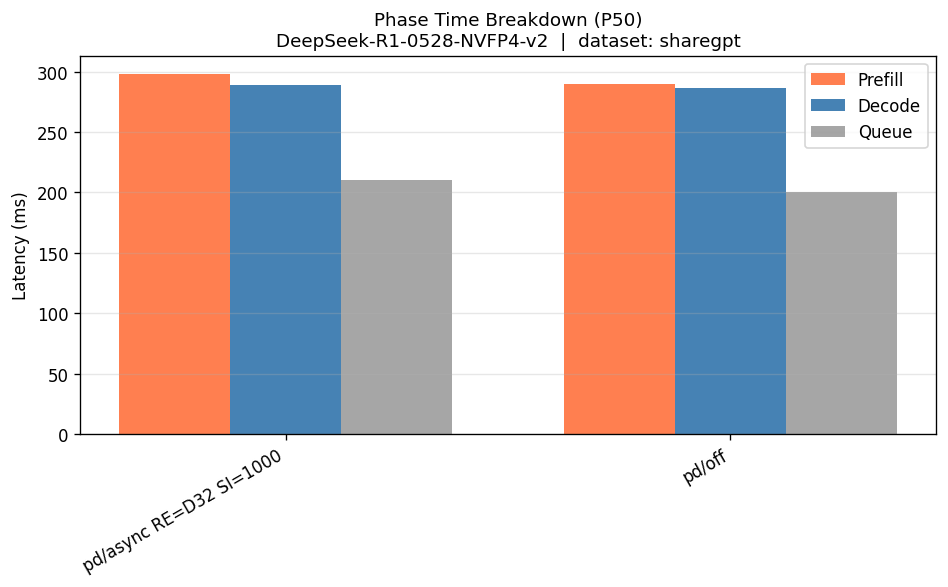

In [80]:
plot_phase_time_comparison(runs, percentile="p50", title="Phase Time Breakdown (P50)")

In [60]:
# Phase fractions of E2E at each stage (p50 and p99)
if smt is not None:
    for pct in ["p50", "p99"]:
        phase_cols = [c for c in [f"queue_{pct}_ms", f"prefill_time_{pct}_ms", f"decode_time_{pct}_ms"] if c in smt.columns]
        e2e_col = f"e2e_{pct}_ms" if f"e2e_{pct}_ms" in smt.columns else None
        if phase_cols and e2e_col:
            fractions = smt[phase_cols].div(smt[e2e_col], axis=0) * 100
            fractions.insert(0, "concurrency", smt["concurrency"])
            print(f"Phase fraction of E2E at {pct} (%):")
            display(fractions)

Phase fraction of E2E at p50 (%):


,concurrency,queue_p50_ms,prefill_time_p50_ms,decode_time_p50_ms
stage,,,,
0,2600,64.785,1.082,0.001
1,3400,0.384,0.384,0.016
2,4200,0.348,0.348,0.023
3,5000,0.309,0.309,0.023


Phase fraction of E2E at p99 (%):


,concurrency,queue_p99_ms,prefill_time_p99_ms,decode_time_p99_ms
stage,,,,
0,2600,41.732,0.839,0.100
1,3400,99.211,0.833,0.099
2,4200,99.566,0.829,0.099
3,5000,99.946,0.420,0.050


No per-stage data for p50


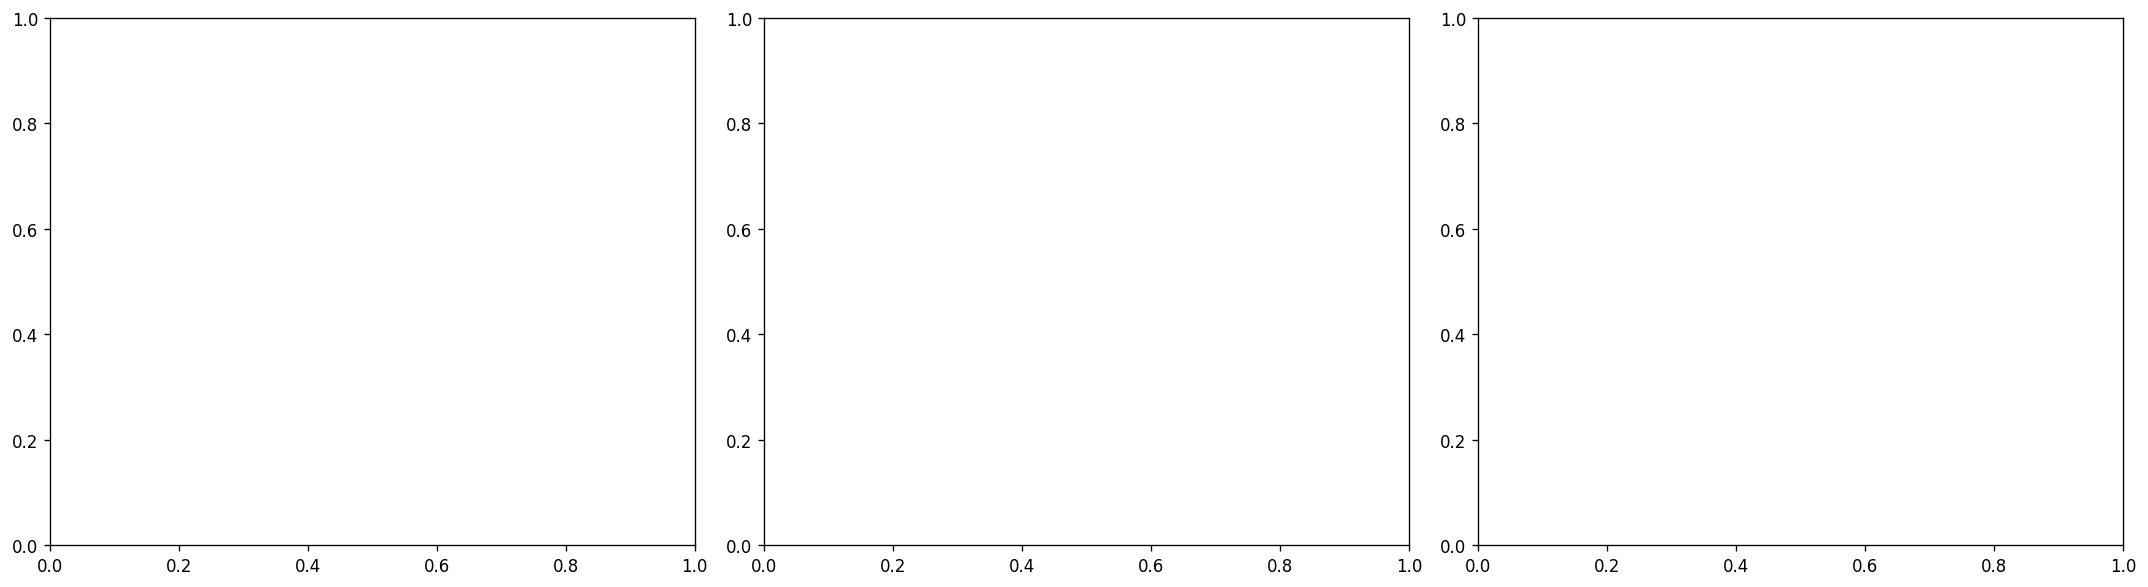

In [ ]:
# Range metrics only available at p99; show p50 instant bars for context
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plt.sca(axes[0])
# plot_latency_timeseries(runs, metric_key="itl_p99_range", title="ITL P99 (time series)")

# plt.sca(axes[1])
# plot_latency_timeseries(runs, metric_key="decode_time_p99_range", title="Decode Time P99 (time series)")

# plt.sca(axes[2])
# plot_latency_timeseries(runs, metric_key="ttft_p99_range", title="TTFT P99 (time series)")

plt.tight_layout()

# P50 bar chart comparison across stages
plot_latency_comparison(runs, metric="p50", title="Latency Comparison (P50)")

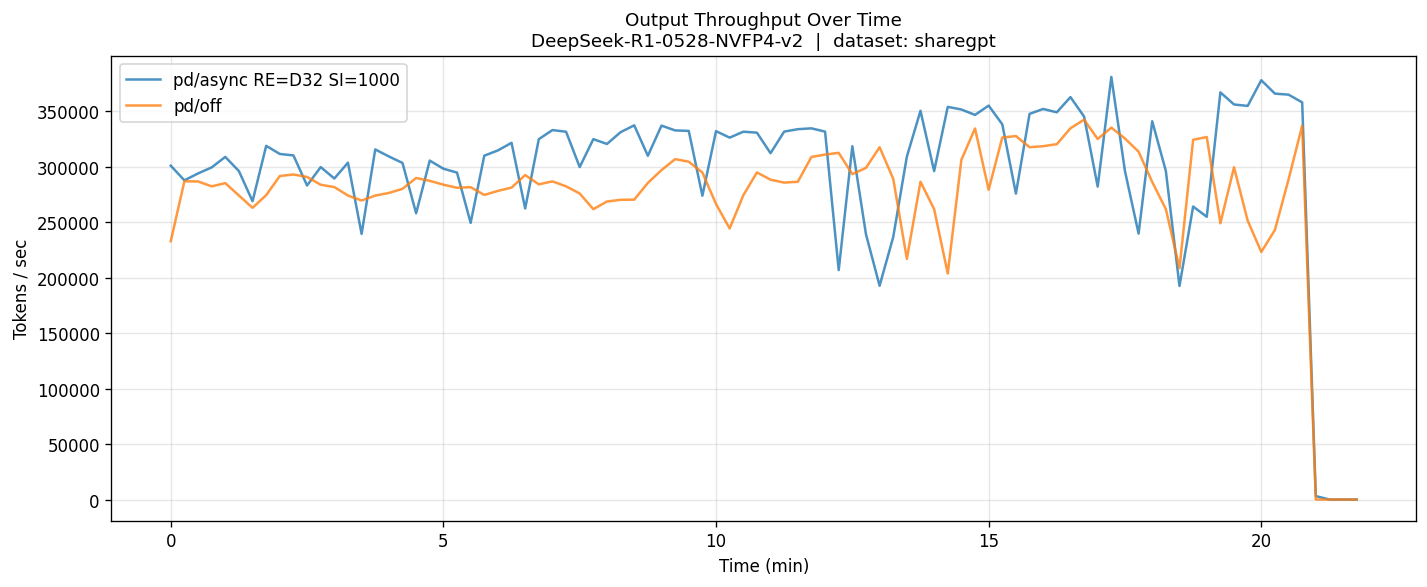

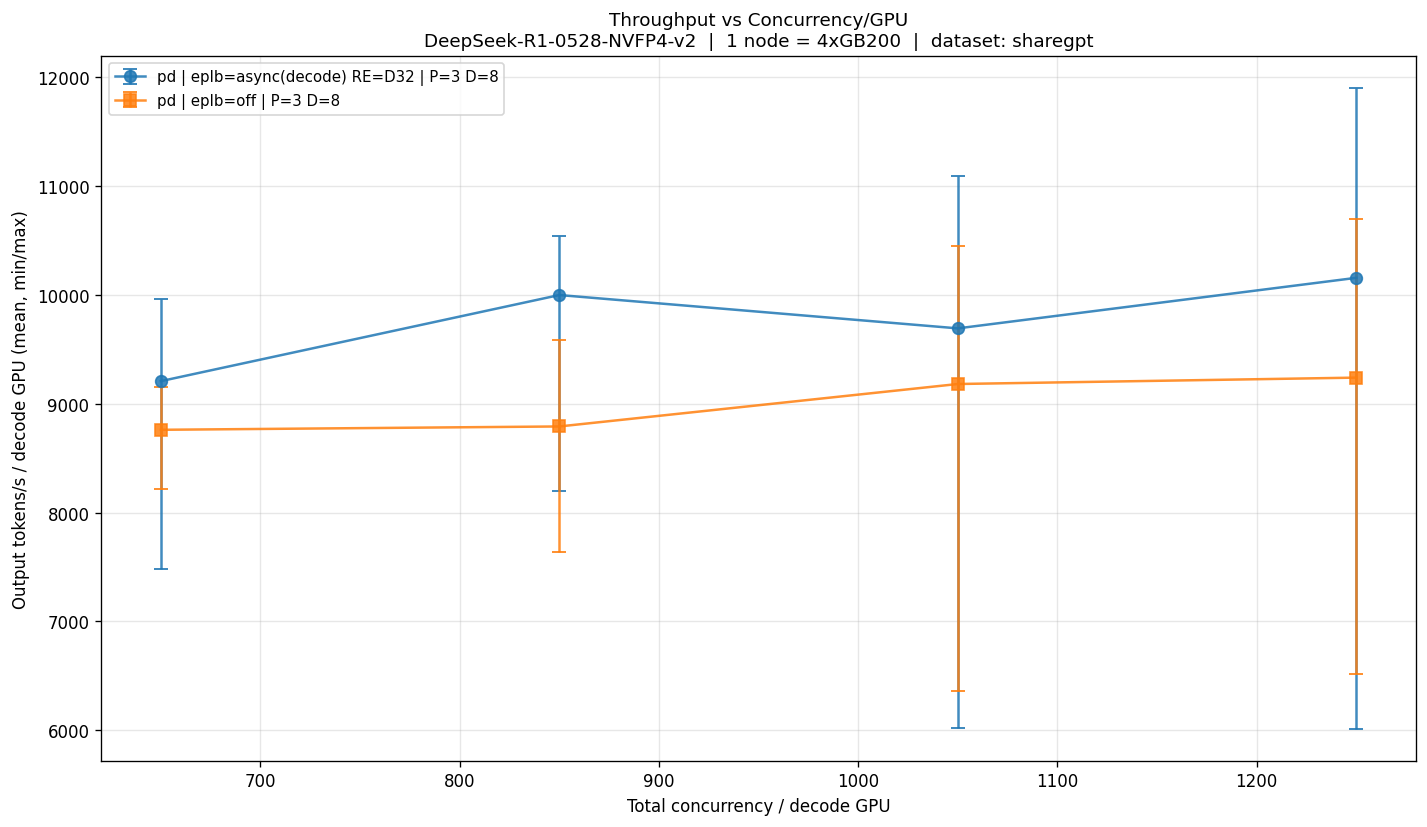

In [86]:
plot_throughput_timeseries(runs, title="Output Throughput Over Time")
plot_throughput_vs_concurrency(runs, gpus_per_pod=4, title="Throughput vs Concurrency/GPU")

In [82]:
# Best run per concurrency level -- compare all runs at each concurrency
from eplb_analysis import stage_metrics_table

all_rows = []
for name, run in runs.items():
    smt_run = stage_metrics_table(run)
    if smt_run is None or "gen_tokens_per_sec" not in smt_run.columns:
        continue
    decode_gpus = (run.config.decode_pods or 8) * 4
    for stage_idx, row in smt_run.iterrows():
        conc = int(row["concurrency"])
        tok_s = row["gen_tokens_per_sec"]
        tok_per_gpu = tok_s / decode_gpus
        itl_p50 = row.get("itl_p50_ms", float("nan"))
        ttft_p50 = row.get("ttft_p50_ms", float("nan"))
        all_rows.append({
            "run": name,
            "concurrency": conc,
            "gen_tok/s": tok_s,
            "tok/s/gpu": tok_per_gpu,
            "itl_p50_ms": itl_p50,
            "ttft_p50_ms": ttft_p50,
        })

if all_rows:
    df_all = pd.DataFrame(all_rows)

    # Best run per concurrency (highest tok/s)
    idx_best = df_all.groupby("concurrency")["gen_tok/s"].idxmax()
    df_best = df_all.loc[idx_best].set_index("concurrency").sort_index()
    print("Best run per concurrency level (highest gen tok/s):")
    display(df_best[["run", "gen_tok/s", "tok/s/gpu", "itl_p50_ms", "ttft_p50_ms"]])

    # Pivot: all runs × concurrency
    print("\nAll runs — tok/s/gpu at each concurrency:")
    pivot = df_all.pivot_table(index="run", columns="concurrency",
                                values="tok/s/gpu", aggfunc="first")
    pivot["peak"] = pivot.max(axis=1)
    pivot = pivot.sort_values("peak", ascending=False)
    display(pivot.round(0).fillna("-"))

Best run per concurrency level (highest gen tok/s):


,run,gen_tok/s,tok/s/gpu,itl_p50_ms,ttft_p50_ms
concurrency,,,,,
2600,pd-async-eplb-sharegpt-v2,296399.673,9262.490,63.097,482.703
3400,pd-async-eplb-sharegpt-v2,320175.903,10005.497,63.549,492.507
4200,pd-async-eplb-sharegpt-v2,312957.522,9779.923,86.376,652.112
5000,pd-async-eplb-sharegpt-v2,330887.603,10340.238,113.107,707.040



All runs — tok/s/gpu at each concurrency:


concurrency,2600,3400,4200,5000,peak
run,,,,,
pd-async-eplb-sharegpt-v2,9262.000,10005.000,9780.000,10340.000,10340.000
pd-baseline-sharegpt-v28,8746.000,8797.000,9196.000,9525.000,9525.000


## 4. Per-Rank Analysis

Key question: do all ranks slow down equally (communication/compute scaling) or do specific ranks lag (topology/thermal)?
- **Flat spread + growing mean** -> all ranks slow equally -> MNNVL/compute scaling
- **Growing spread** -> rank-specific issue -> topology, thermal, NIXL pod placement

In [70]:
# Per-rank stats across all stages
if prom.n_stages > 0:
    for stage_idx in range(prom.n_stages):
        stage_meta = prom.get_stages()[stage_idx]
        print(f"\n--- Stage {stage_idx} (concurrency={stage_meta['concurrency']}) ---")
        stats = per_rank_stats_table(runs, role="decode", stage=stage_idx)
        display(stats)


--- Stage 0 (concurrency=2600) ---


mean     std  \
run                     concurrency metric                                
pd/async RE=D32 SI=1000 2600        itl_p50              38.797   0.014   
                                    itl_p99              87.594   0.279   
                                    decode_time_p50      74.147   0.794   
                                    decode_time_p99     119.083   0.016   
                                    gen_tokens_per_sec 8282.622 263.628   
pd/off                  2600        itl_p50              43.891   0.200   
                                    itl_p99              74.862   0.015   
                                    decode_time_p50      80.572   0.554   
                                    decode_time_p99     119.211   0.011   
                                    gen_tokens_per_sec 8175.472 218.055   

                                                            min      max  \
run                     concurrency metric                                 
pd/async RE=D32 SI=1000 2600        itl_p50              38.758   38.822   
                                    itl_p99              86.878   88.331   
                                    decode_time_p50      72.611   75.581   
                                    decode_time_p99     119.052  119.112   
                                    gen_tokens_per_sec 7626.889 8846.778   
pd/off                  2600        itl_p50              43.380   44.274   
                                    itl_p99              74.831   74.894   
                                    decode_time_p50      79.234   81.812   
                                    decode_time_p99     119.185  119.236   
                                    gen_tokens_per_sec 7529.778 8511.556   

                                                        max/mean  min_rank  \
run                     concurrency metric                                   
pd/async RE=D32 SI=1000 2600        itl_p50                1.001         5   
                                    itl_p99                1.008         9   
                                    decode_time_p50        1.019         9   
                                    decode_time_p99        1.000         9   
                                    gen_tokens_per_sec     1.068         5   
pd/off                  2600        itl_p50                1.009        11   
                                    itl_p99                1.000         3   
                                    decode_time_p50        1.015        23   
                                    decode_time_p99        1.000        23   
                                    gen_tokens_per_sec     1.041        24   

                                                        max_rank  
run                     concurrency metric                        
pd/async RE=D32 SI=1000 2600        itl_p50                   19  
                                    itl_p99                   25  
                                    decode_time_p50            4  
                                    decode_time_p99            4  
                                    gen_tokens_per_sec        12  
pd/off                  2600        itl_p50                   16  
                                    itl_p99                   22  
                                    decode_time_p50           20  
                                    decode_time_p99           20  
                                    gen_tokens_per_sec        11


--- Stage 1 (concurrency=3400) ---


mean     std  \
run                     concurrency metric                                
pd/async RE=D32 SI=1000 3400        itl_p50              38.854   0.014   
                                    itl_p99              91.006   0.155   
                                    decode_time_p50      78.605   0.629   
                                    decode_time_p99     119.172   0.013   
                                    gen_tokens_per_sec 8290.503 207.251   
pd/off                  3400        itl_p50              37.931   0.008   
                                    itl_p99              69.185   0.161   
                                    decode_time_p50      78.021   0.607   
                                    decode_time_p99     119.160   0.012   
                                    gen_tokens_per_sec 8228.674 202.746   

                                                            min      max  \
run                     concurrency metric                                 
pd/async RE=D32 SI=1000 3400        itl_p50              38.833   38.891   
                                    itl_p99              90.751   91.306   
                                    decode_time_p50      77.452   80.000   
                                    decode_time_p99     119.149  119.200   
                                    gen_tokens_per_sec 7858.667 8699.333   
pd/off                  3400        itl_p50              37.911   37.948   
                                    itl_p99              68.866   69.662   
                                    decode_time_p50      76.646   79.857   
                                    decode_time_p99     119.133  119.197   
                                    gen_tokens_per_sec 7837.333 8753.556   

                                                        max/mean  min_rank  \
run                     concurrency metric                                   
pd/async RE=D32 SI=1000 3400        itl_p50                1.001        15   
                                    itl_p99                1.003        10   
                                    decode_time_p50        1.018         1   
                                    decode_time_p99        1.000         1   
                                    gen_tokens_per_sec     1.049         4   
pd/off                  3400        itl_p50                1.000        27   
                                    itl_p99                1.007         2   
                                    decode_time_p50        1.024        17   
                                    decode_time_p99        1.000        17   
                                    gen_tokens_per_sec     1.064        31   

                                                        max_rank  
run                     concurrency metric                        
pd/async RE=D32 SI=1000 3400        itl_p50                    0  
                                    itl_p99                   23  
                                    decode_time_p50           11  
                                    decode_time_p99           11  
                                    gen_tokens_per_sec        11  
pd/off                  3400        itl_p50                   13  
                                    itl_p99                   13  
                                    decode_time_p50           29  
                                    decode_time_p99           29  
                                    gen_tokens_per_sec         9


--- Stage 2 (concurrency=4200) ---


mean     std  \
run                     concurrency metric                                
pd/async RE=D32 SI=1000 4200        itl_p50              38.754   0.012   
                                    itl_p99              89.772   0.222   
                                    decode_time_p50      79.365   0.545   
                                    decode_time_p99     119.187   0.011   
                                    gen_tokens_per_sec 8273.135 259.054   
pd/off                  4200        itl_p50              38.017   0.028   
                                    itl_p99              70.281   0.248   
                                    decode_time_p50      78.434   0.547   
                                    decode_time_p99     119.169   0.011   
                                    gen_tokens_per_sec 8182.361 244.238   

                                                            min      max  \
run                     concurrency metric                                 
pd/async RE=D32 SI=1000 4200        itl_p50              38.728   38.778   
                                    itl_p99              89.413   90.176   
                                    decode_time_p50      78.130   80.616   
                                    decode_time_p99     119.163  119.212   
                                    gen_tokens_per_sec 7735.333 8722.556   
pd/off                  4200        itl_p50              37.989   38.104   
                                    itl_p99              69.922   70.997   
                                    decode_time_p50      77.333   79.302   
                                    decode_time_p99     119.147  119.186   
                                    gen_tokens_per_sec 7711.222 8653.000   

                                                        max/mean  min_rank  \
run                     concurrency metric                                   
pd/async RE=D32 SI=1000 4200        itl_p50                1.001         2   
                                    itl_p99                1.004         0   
                                    decode_time_p50        1.016        18   
                                    decode_time_p99        1.000        18   
                                    gen_tokens_per_sec     1.054        15   
pd/off                  4200        itl_p50                1.002         9   
                                    itl_p99                1.010        28   
                                    decode_time_p50        1.011        15   
                                    decode_time_p99        1.000        15   
                                    gen_tokens_per_sec     1.058         9   

                                                        max_rank  
run                     concurrency metric                        
pd/async RE=D32 SI=1000 4200        itl_p50                   31  
                                    itl_p99                   17  
                                    decode_time_p50            2  
                                    decode_time_p99            2  
                                    gen_tokens_per_sec        27  
pd/off                  4200        itl_p50                   20  
                                    itl_p99                   20  
                                    decode_time_p50           27  
                                    decode_time_p99           27  
                                    gen_tokens_per_sec        15


--- Stage 3 (concurrency=5000) ---


mean     std  \
run                     concurrency metric                                
pd/async RE=D32 SI=1000 5000        itl_p50              38.754   0.013   
                                    itl_p99              89.430   0.236   
                                    decode_time_p50      78.013   0.615   
                                    decode_time_p99     119.160   0.012   
                                    gen_tokens_per_sec 8640.509 241.412   
pd/off                  5000        itl_p50              38.657   0.083   
                                    itl_p99              72.600   0.167   
                                    decode_time_p50      78.462   0.676   
                                    decode_time_p99     119.169   0.014   
                                    gen_tokens_per_sec 8420.542 231.085   

                                                            min      max  \
run                     concurrency metric                                 
pd/async RE=D32 SI=1000 5000        itl_p50              38.716   38.780   
                                    itl_p99              88.987   89.951   
                                    decode_time_p50      76.774   78.919   
                                    decode_time_p99     119.135  119.178   
                                    gen_tokens_per_sec 8230.944 9105.833   
pd/off                  5000        itl_p50              38.546   38.869   
                                    itl_p99              72.341   72.986   
                                    decode_time_p50      77.124   80.314   
                                    decode_time_p99     119.142  119.206   
                                    gen_tokens_per_sec 7936.611 8767.278   

                                                        max/mean  min_rank  \
run                     concurrency metric                                   
pd/async RE=D32 SI=1000 5000        itl_p50                1.001        26   
                                    itl_p99                1.006        27   
                                    decode_time_p50        1.012         8   
                                    decode_time_p99        1.000         8   
                                    gen_tokens_per_sec     1.054         1   
pd/off                  5000        itl_p50                1.005        15   
                                    itl_p99                1.005        15   
                                    decode_time_p50        1.024        12   
                                    decode_time_p99        1.000        12   
                                    gen_tokens_per_sec     1.041        22   

                                                        max_rank  
run                     concurrency metric                        
pd/async RE=D32 SI=1000 5000        itl_p50                   31  
                                    itl_p99                   17  
                                    decode_time_p50           21  
                                    decode_time_p99           21  
                                    gen_tokens_per_sec        25  
pd/off                  5000        itl_p50                   23  
                                    itl_p99                   23  
                                    decode_time_p50           22  
                                    decode_time_p99           22  
                                    gen_tokens_per_sec        15

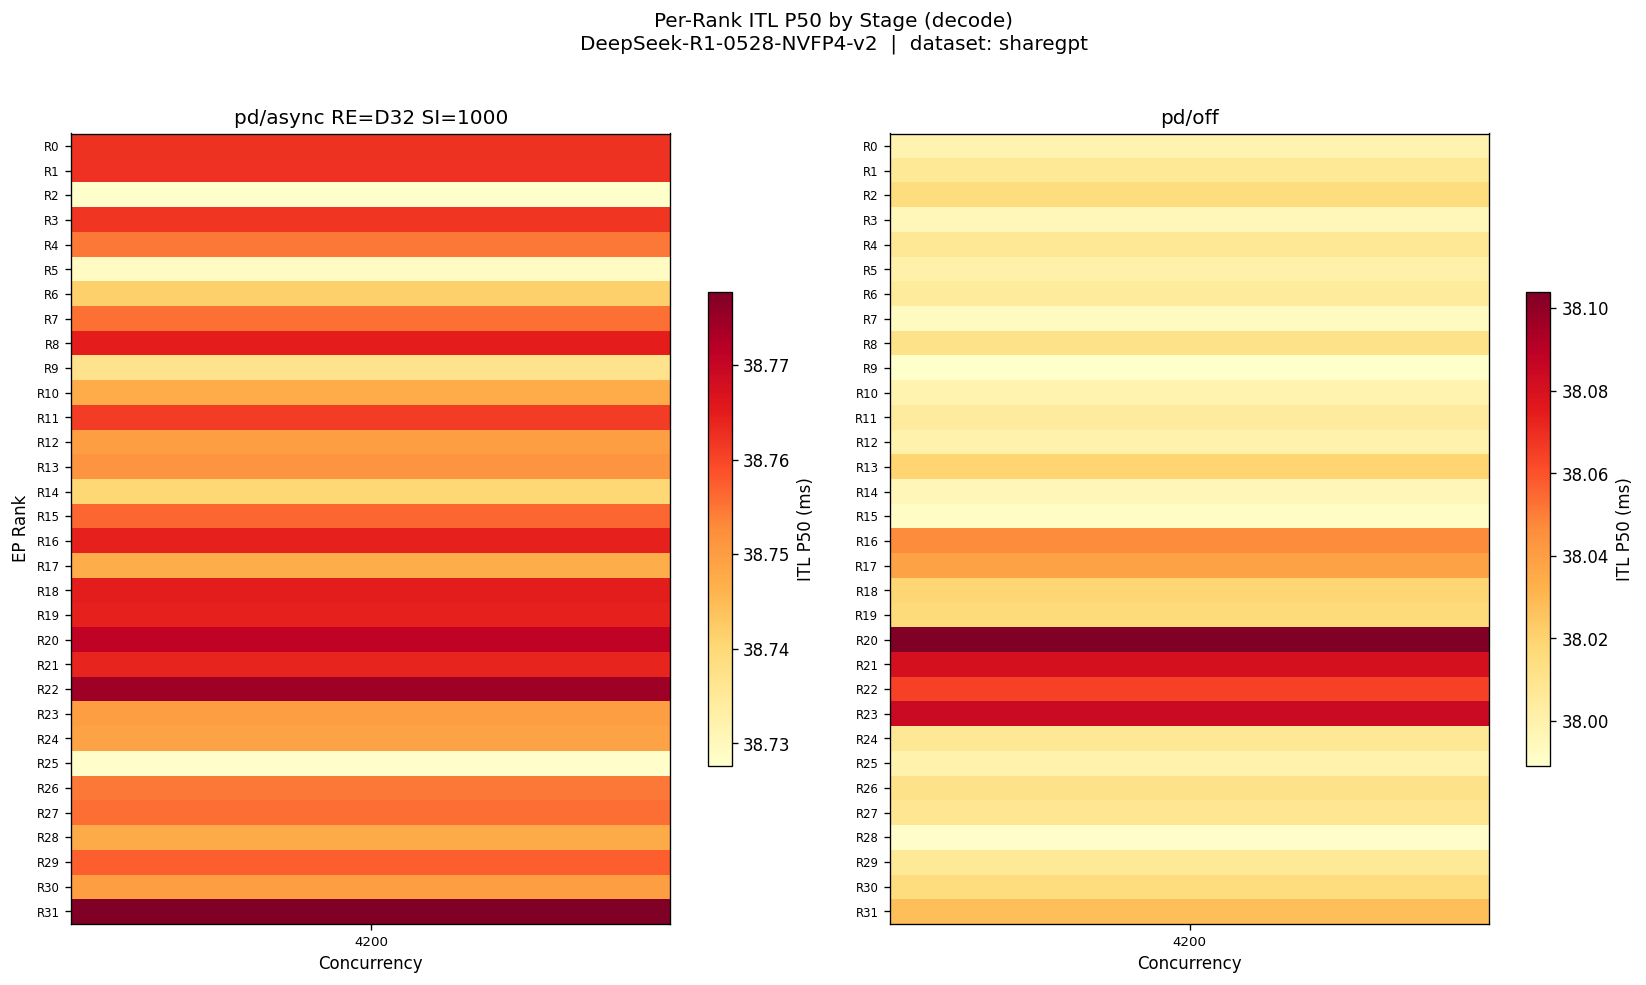

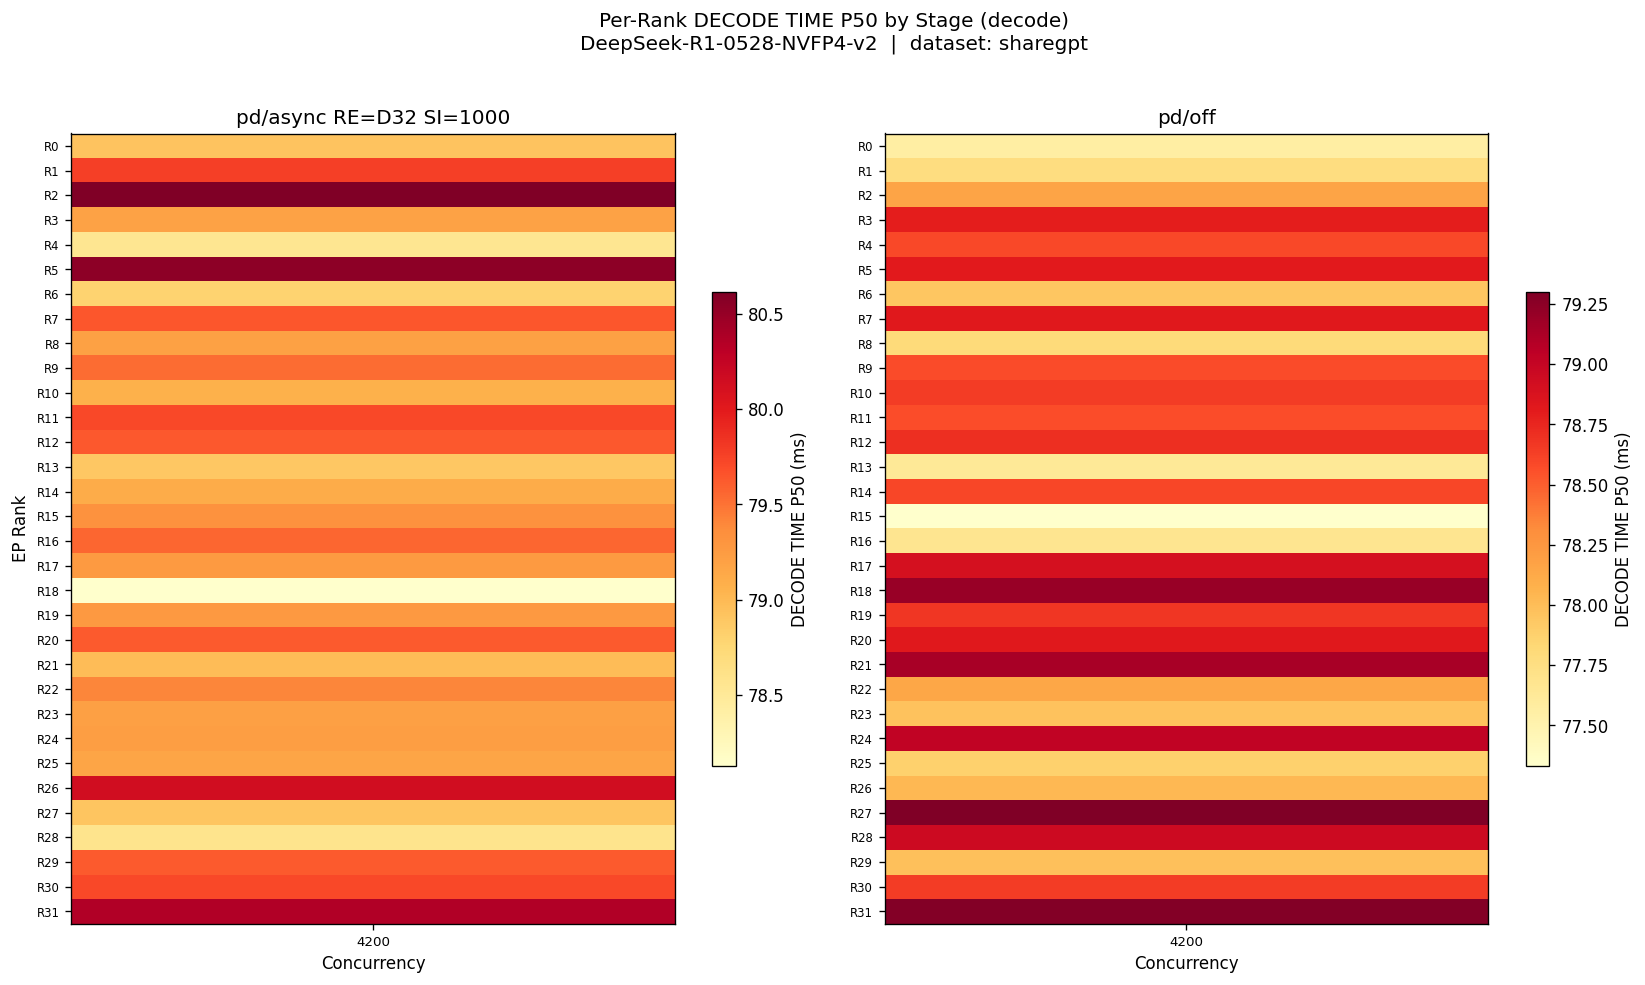

In [72]:
# P50 heatmaps (primary -- shows systemic behavior)
plot_per_rank_latency_heatmap(runs, metric="itl_p50", role="decode", stage=2)
plot_per_rank_latency_heatmap(runs, metric="decode_time_p50", role="decode", stage=2)

# P99 heatmaps (secondary -- tail latency)
# plot_per_rank_latency_heatmap(runs, metric="itl_p99", role="decode")
# plot_per_rank_latency_heatmap(runs, metric="decode_time_p99", role="decode")

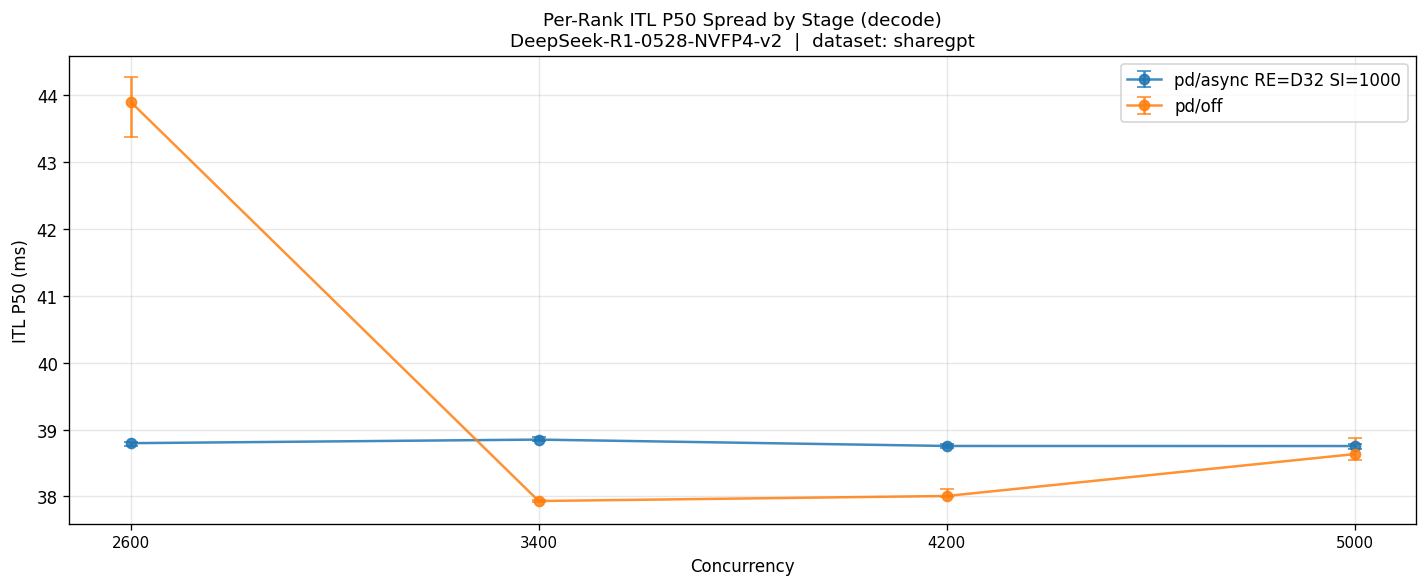

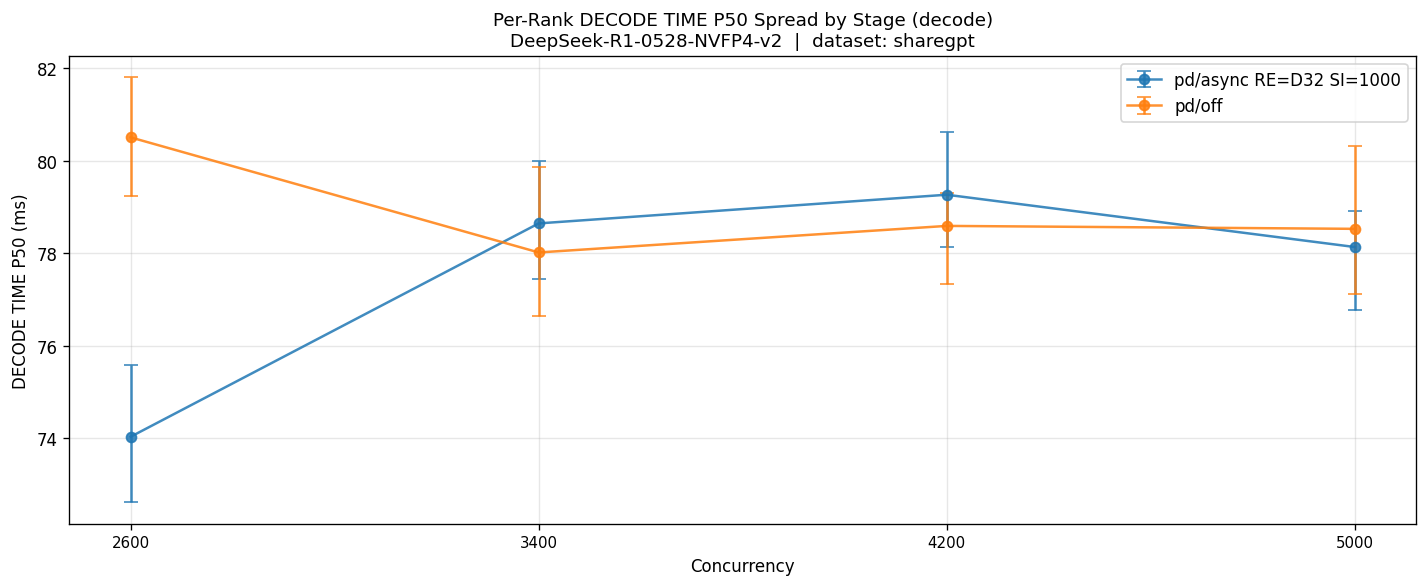

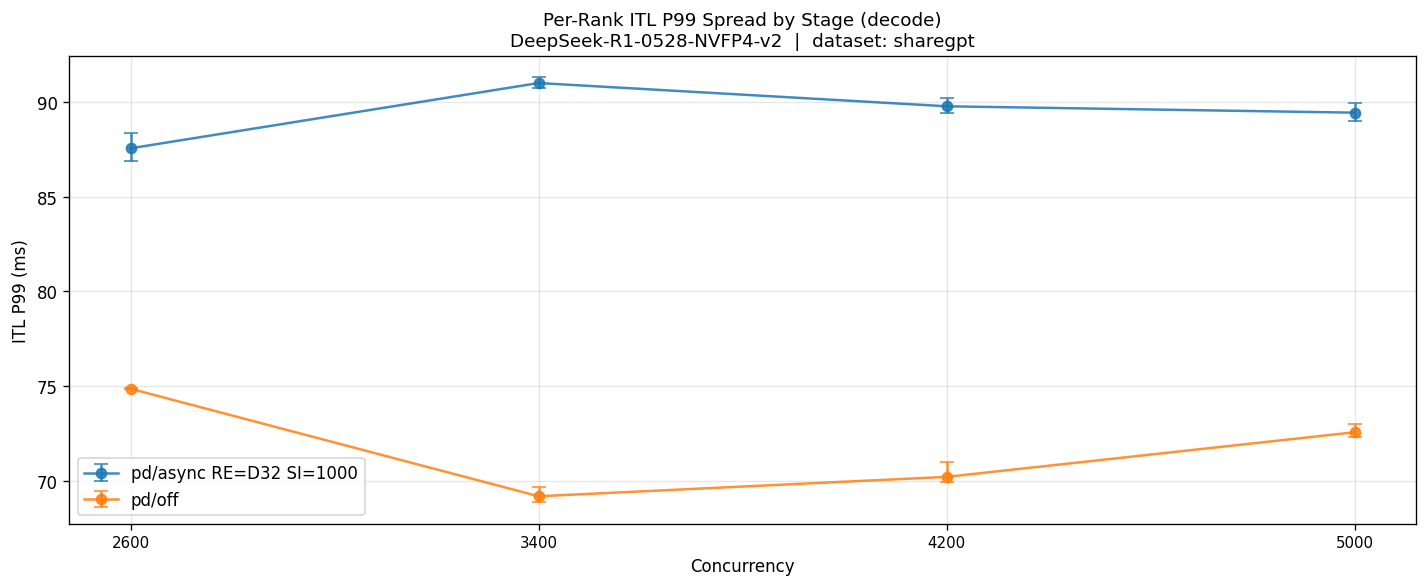

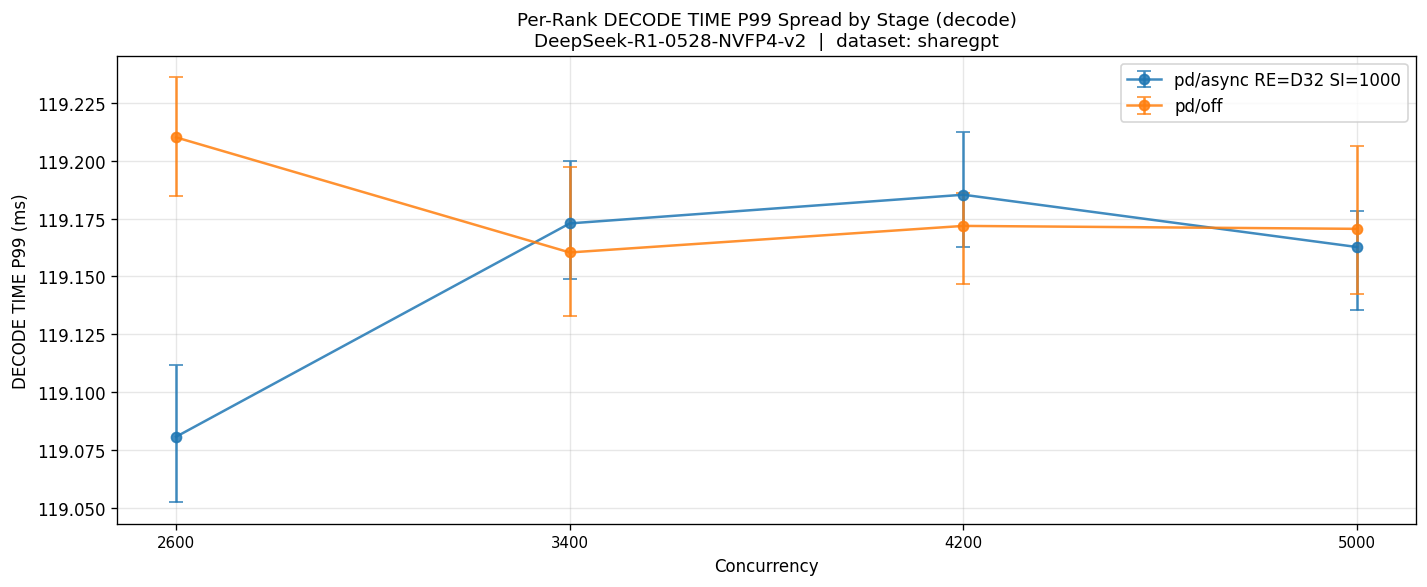

In [73]:
# P50 spread (primary)
plot_per_rank_latency_spread(runs, metric="itl_p50", role="decode")
plot_per_rank_latency_spread(runs, metric="decode_time_p50", role="decode")

# P99 spread (secondary)
plot_per_rank_latency_spread(runs, metric="itl_p99", role="decode")
plot_per_rank_latency_spread(runs, metric="decode_time_p99", role="decode")

Comparing stage 2 (peak) vs stage 3 (worst):


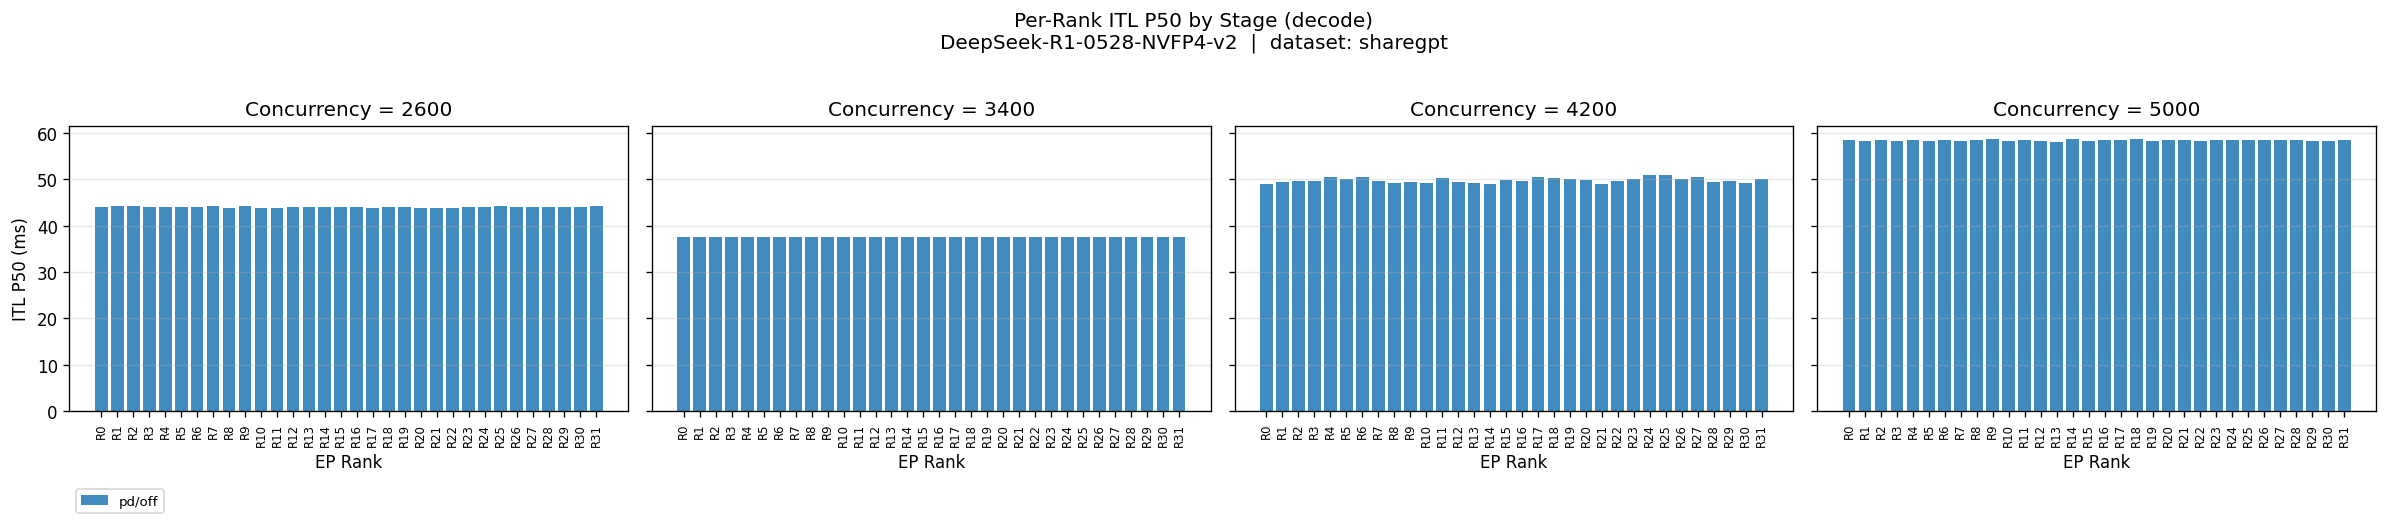

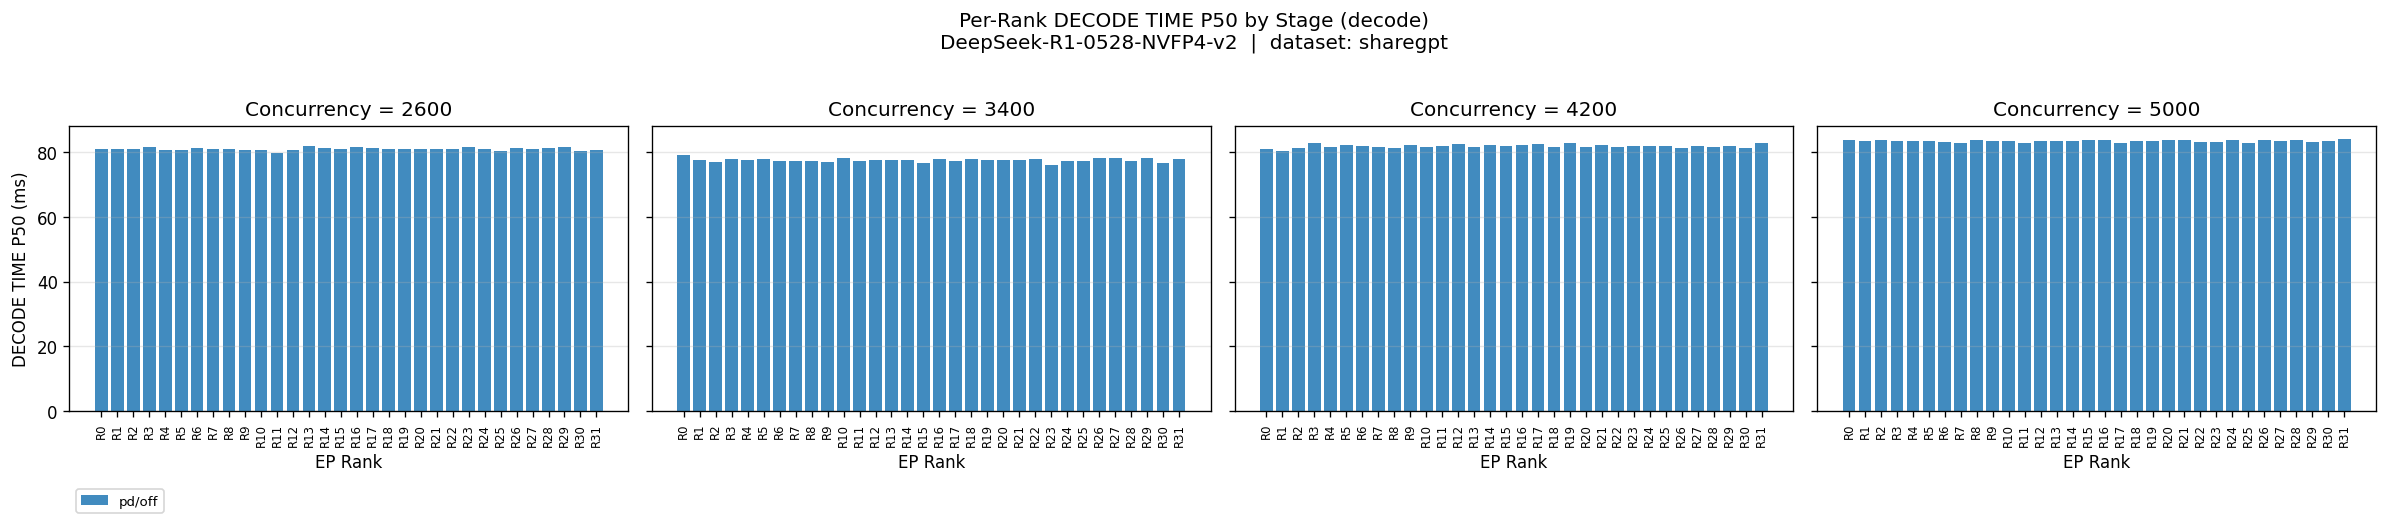

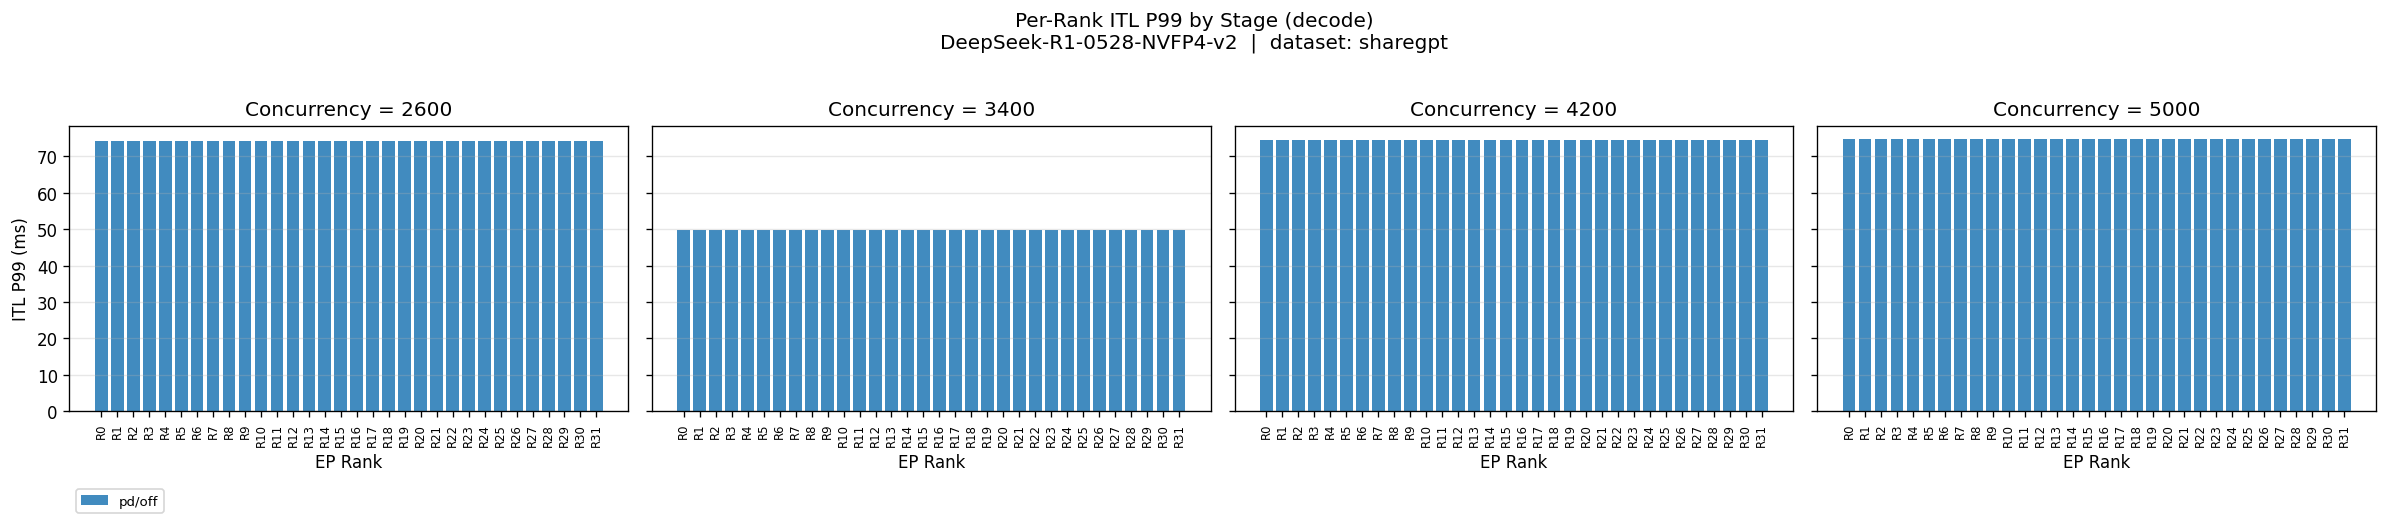

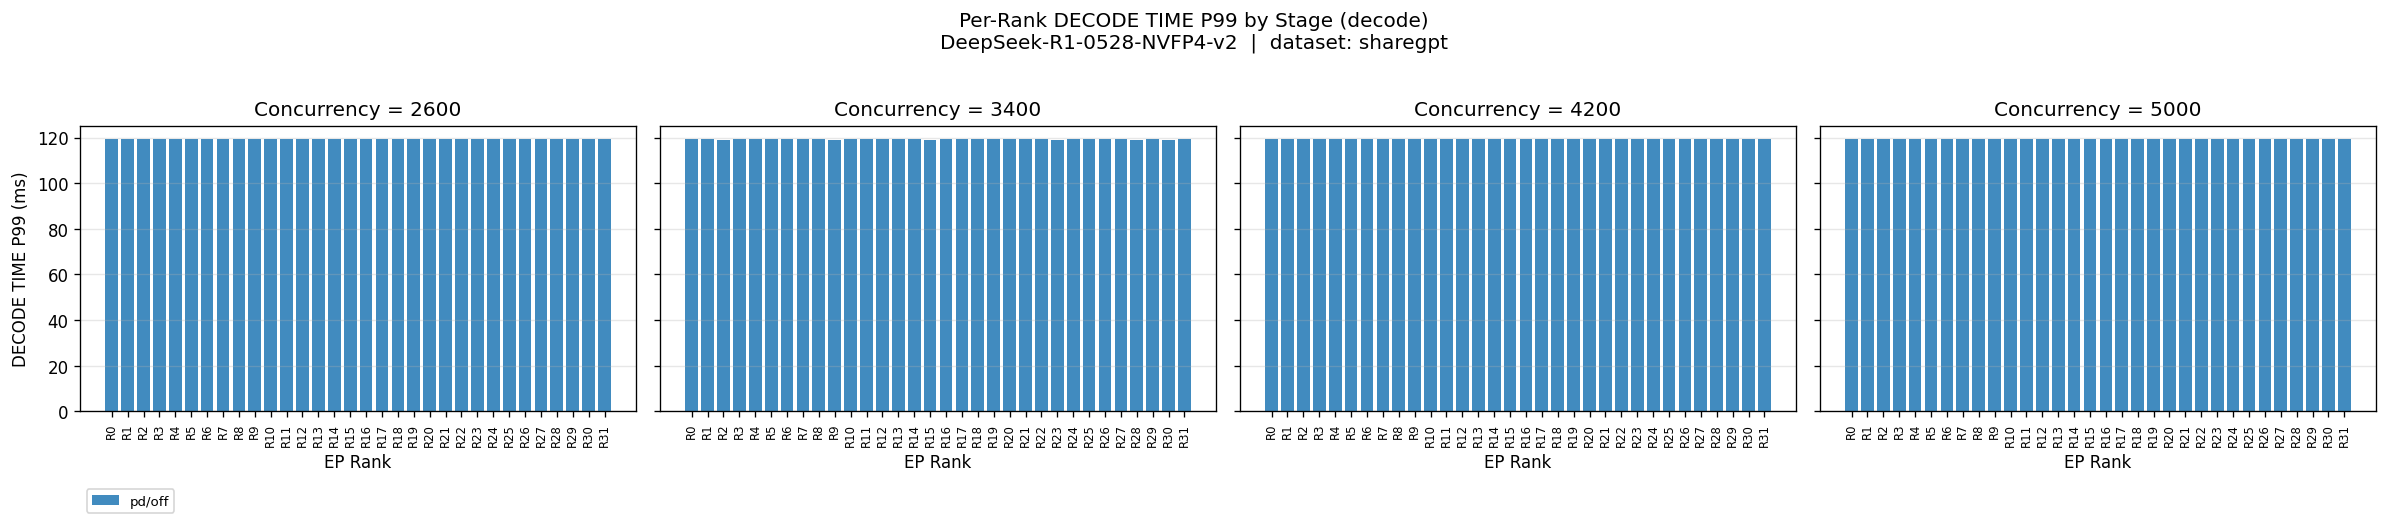

In [134]:
# Compare peak stage vs worst stage (p50 primary, p99 secondary)
if smt is not None and "gen_tokens_per_sec" in smt.columns:
    peak = int(smt["gen_tokens_per_sec"].idxmax())
    worst = int(smt["gen_tokens_per_sec"].idxmin())
    print(f"Comparing stage {peak} (peak) vs stage {worst} (worst):")
    plot_per_rank_comparison(runs, metric="itl_p50", role="decode")
    plot_per_rank_comparison(runs, metric="decode_time_p50", role="decode")
    plot_per_rank_comparison(runs, metric="itl_p99", role="decode")
    plot_per_rank_comparison(runs, metric="decode_time_p99", role="decode")

## 5. Queue Depth + Scheduling

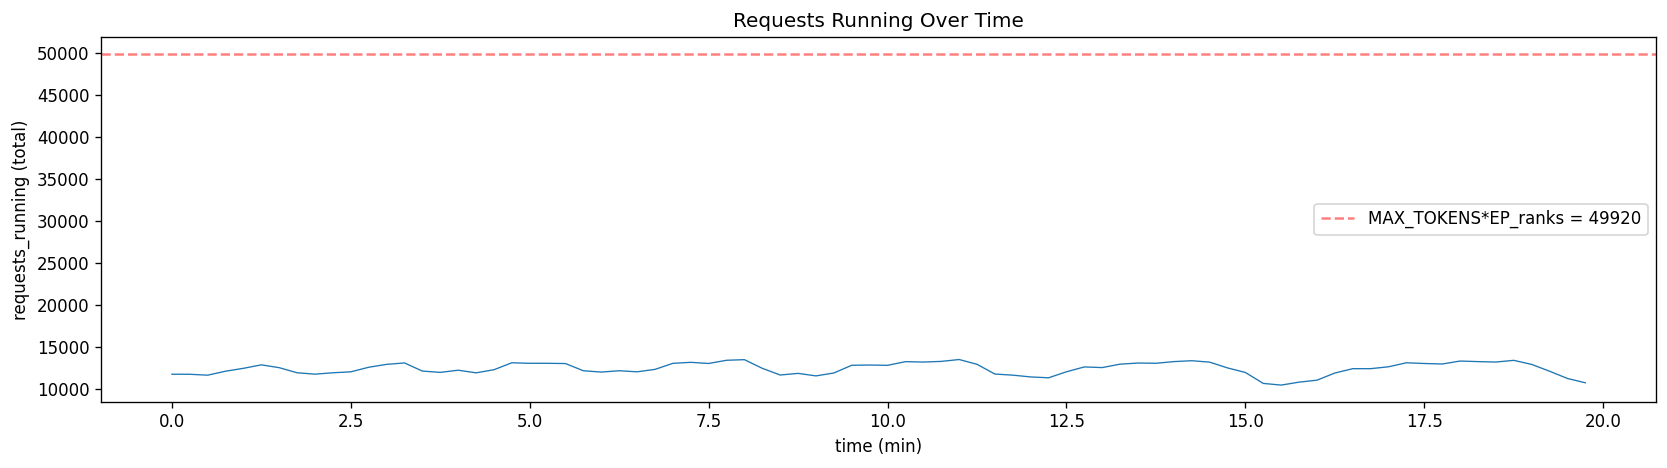

In [51]:
# requests_running time series -- is the system hitting MAX_TOKENS=1024?
# Clip to benchmark window (first stage start -> last stage end)
stages = prom.get_stages()
bench_start = stages[0]["start_time"] if stages else None
bench_end = stages[-1]["end_time"] if stages else None

df = prom.range_series("requests_running_range")
if df is not None and bench_start is not None:
    df = df[(df["timestamp"] >= bench_start) & (df["timestamp"] <= bench_end)].copy()
    df["time_min"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 60
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["time_min"], df["value"], linewidth=0.8)
    ax.axhline(y=1560 * 32, color="r", linestyle="--", alpha=0.5, label=f"MAX_TOKENS*EP_ranks = {1560*32}")
    ax.set_ylabel("requests_running (total)")
    ax.set_xlabel("time (min)")
    ax.set_title("Requests Running Over Time")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No requests_running_range data")

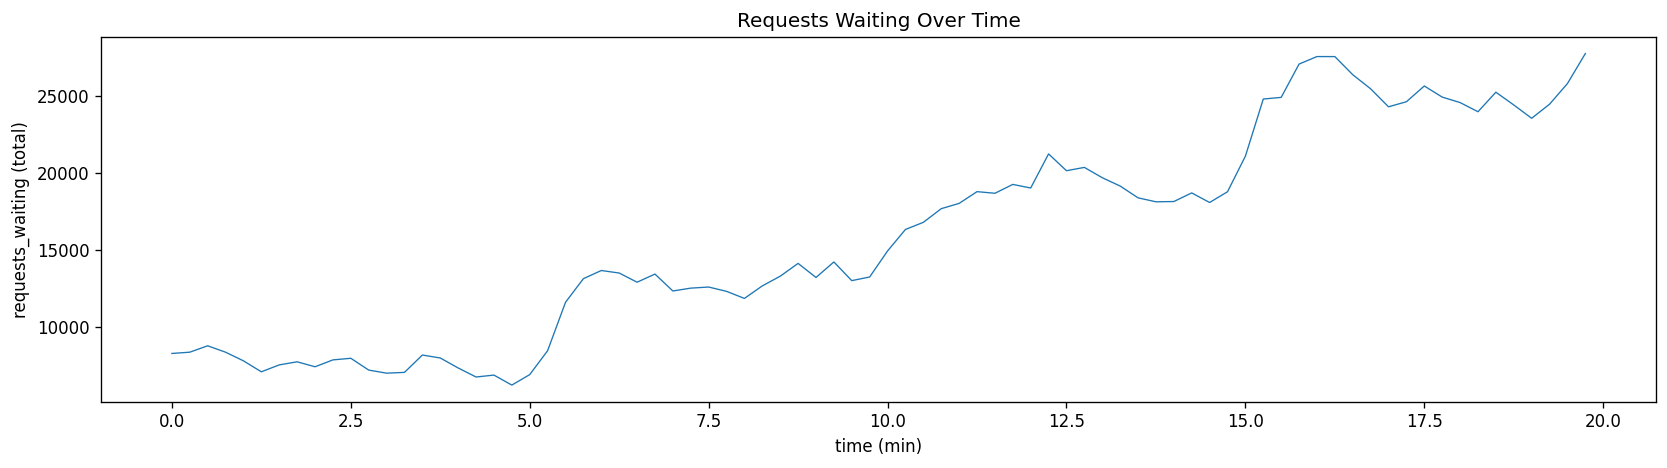

In [52]:
# requests_waiting time series (clipped to benchmark window)
df = prom.range_series("requests_waiting_range")
if df is not None and bench_start is not None:
    df = df[(df["timestamp"] >= bench_start) & (df["timestamp"] <= bench_end)].copy()
    df["time_min"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 60
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["time_min"], df["value"], linewidth=0.8)
    ax.set_ylabel("requests_waiting (total)")
    ax.set_xlabel("time (min)")
    ax.set_title("Requests Waiting Over Time")
    plt.tight_layout()
    plt.show()
else:
    print("No requests_waiting_range data")

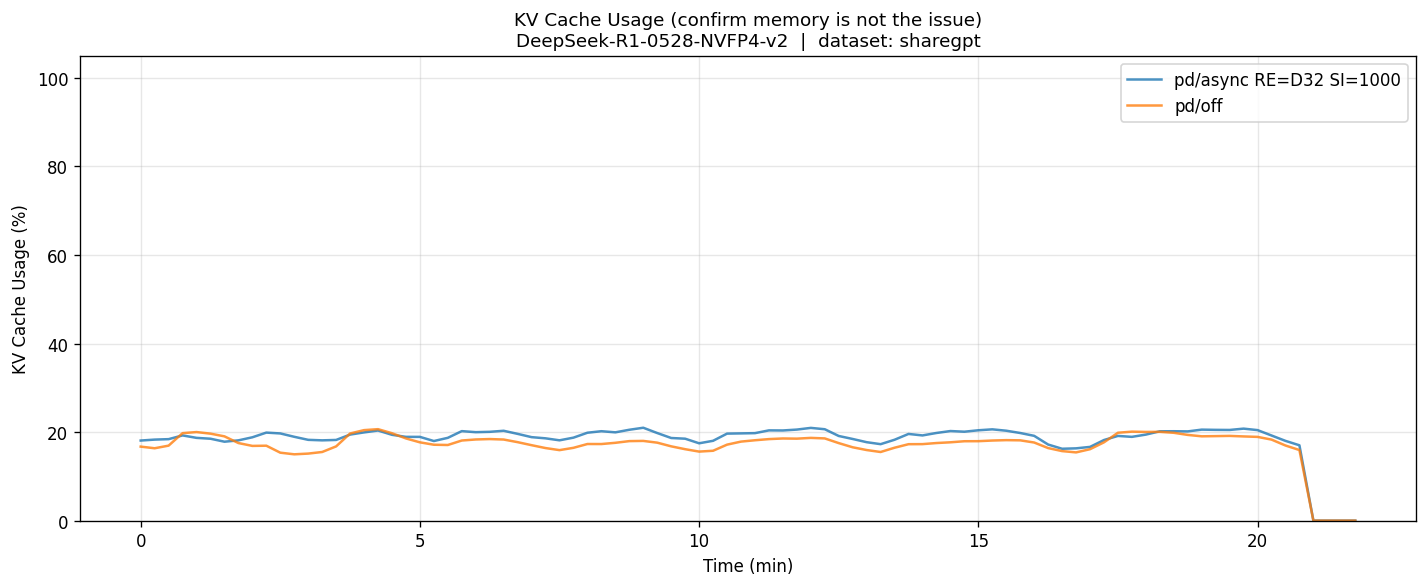

In [53]:
plot_kv_cache_usage(runs, title="KV Cache Usage (confirm memory is not the issue)")

In [54]:
# New metrics (available after re-collecting with updated collect-prometheus.py)
new_instant_keys = [
    "iteration_tokens_p50", "iteration_tokens_p99",
    "nixl_xfer_p50", "nixl_xfer_p99",
    "nixl_bytes_p50", "nixl_bytes_p99",
    "nixl_post_time_p50", "nixl_post_time_p99",
    "nixl_descriptors_p50", "nixl_descriptors_p99",
    "nixl_failed_transfers_rate", "nixl_failed_notifications_rate", "nixl_kv_expired_rate",
    "preemptions_rate",
    "requests_waiting_capacity", "requests_waiting_deferred",
    "prefix_cache_queries_rate", "prefix_cache_hits_rate",
    "decode_prompt_tokens_local_compute_rate", "decode_prompt_tokens_local_cache_hit_rate",
    "decode_prompt_tokens_external_kv_transfer_rate", "decode_request_success_rate",
    "prefill_kv_computed_p50", "prefill_kv_computed_p99",
    "prefill_requests_running", "prefill_requests_waiting",
    "prefill_kv_cache_usage",
    "prefill_gen_tokens_per_sec", "prefill_prompt_tokens_per_sec",
    "prefill_iteration_tokens_p50", "prefill_iteration_tokens_p99",
    # Decode-only scoped metrics
    "decode_iteration_tokens_p50", "decode_iteration_tokens_p99",
    "decode_requests_running", "decode_requests_waiting",
    "decode_kv_cache_usage", "decode_gen_tokens_per_sec",
]

if prom.n_stages > 0:
    rows = []
    for stage_meta in prom.get_stages():
        idx = stage_meta["stage"]
        row = {"stage": idx, "concurrency": stage_meta["concurrency"]}
        for key in new_instant_keys:
            v = prom.stage_instant(idx, key)
            if v is not None:
                row[key] = v
        rows.append(row)
    new_df = pd.DataFrame(rows).set_index("stage")
    has_new = len(new_df.columns) > 1  # more than just concurrency
    if has_new:
        print("New metrics per stage (from updated collect-prometheus.py):")
        display(new_df)
    else:
        print("New metrics not yet collected. Re-run collect-prometheus.py with the updated script.")

New metrics per stage (from updated collect-prometheus.py):


,concurrency,iteration_tokens_p50,iteration_tokens_p99,nixl_xfer_p50,nixl_xfer_p99,nixl_bytes_p50,nixl_bytes_p99,nixl_post_time_p50,nixl_post_time_p99,nixl_descriptors_p50,nixl_descriptors_p99,nixl_failed_transfers_rate,nixl_failed_notifications_rate,nixl_kv_expired_rate,preemptions_rate,requests_waiting_capacity,requests_waiting_deferred,prefix_cache_queries_rate,prefix_cache_hits_rate,decode_prompt_tokens_local_compute_rate,decode_prompt_tokens_local_cache_hit_rate,decode_prompt_tokens_external_kv_transfer_rate,decode_request_success_rate,prefill_kv_computed_p50,prefill_kv_computed_p99,prefill_requests_running,prefill_requests_waiting,prefill_kv_cache_usage,prefill_gen_tokens_per_sec,prefill_prompt_tokens_per_sec,prefill_iteration_tokens_p50,prefill_iteration_tokens_p99,decode_iteration_tokens_p50,decode_iteration_tokens_p99,decode_requests_running,decode_requests_waiting,decode_kv_cache_usage,decode_gen_tokens_per_sec
stage,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2600,97.694,1816.738,0.022,0.092,21059795.703,33509088.319,0.006,0.019,1243.823,1990.709,0.000,0.000,0.000,0.000,6849.000,28.000,224840.264,287.559,0.000,110.308,112293.151,193.425,211.642,989.979,67.000,6849.000,0.006,197.803,112399.284,1281.407,4007.616,95.129,985.183,12965.000,28.000,0.248,260644.528
1,3400,100.098,1785.622,0.022,0.092,21048806.912,33458755.540,0.006,0.018,1252.150,1989.708,0.000,0.000,0.003,0.000,14890.000,23.000,221860.344,0.856,0.000,0.214,110956.341,197.525,0.998,988.784,64.000,14890.000,0.006,196.652,110904.722,1227.034,3988.693,97.623,983.253,12724.000,23.000,0.246,264904.545
2,4200,100.471,1778.714,0.024,0.093,21049674.199,33479705.182,0.006,0.019,1285.176,1991.132,0.000,0.000,0.003,0.000,21051.000,24.000,221389.239,1.498,0.000,0.000,110710.953,197.766,0.992,989.784,69.000,21051.000,0.005,194.789,110658.640,1209.011,3989.332,97.960,981.168,11870.000,24.000,0.238,265525.756
3,5000,97.236,1755.928,0.024,0.094,21071320.518,33529809.995,0.006,0.020,1284.301,1993.027,0.000,0.000,0.000,0.000,27723.000,22.000,220185.077,294.843,0.000,99.124,110013.106,197.891,0.990,990.268,65.000,27723.000,0.005,193.746,110084.567,1193.669,3981.981,94.812,979.786,10646.000,22.000,0.211,262585.208


NIXL transfer + decode local compute metrics per stage:


,concurrency,nixl_xfer_p50_ms,nixl_xfer_p99_ms,nixl_post_time_p50_ms,nixl_post_time_p99_ms,nixl_bytes_p50,nixl_bytes_p99,nixl_descriptors_p50,nixl_descriptors_p99,nixl_failed_transfers_rate,nixl_kv_expired_rate,decode_prompt_tokens_local_compute_rate,decode_prompt_tokens_external_kv_transfer_rate,decode_request_success_rate,prefill_kv_computed_p50,prefill_kv_computed_p99
stage,,,,,,,,,,,,,,,,
0,2600,21.538,92.269,5.907,18.964,21059795.703,33509088.319,1243.823,1990.709,0.000,0.000,0.000,112293.151,193.425,211.642,989.979
1,3400,22.181,92.166,5.872,17.725,21048806.912,33458755.540,1252.150,1989.708,0.000,0.003,0.000,110956.341,197.525,0.998,988.784
2,4200,24.373,93.420,5.984,18.625,21049674.199,33479705.182,1285.176,1991.132,0.000,0.003,0.000,110710.953,197.766,0.992,989.784
3,5000,24.122,93.851,6.061,20.259,21071320.518,33529809.995,1284.301,1993.027,0.000,0.000,0.000,110013.106,197.891,0.990,990.268



NIXL xfer latency deltas (ms):


,concurrency,nixl_xfer_p50_ms,nixl_xfer_p99_ms
stage,,,
1,3400,0.642,-0.103
2,4200,2.193,1.253
3,5000,-0.251,0.431



Decode local compute (decode pods only):


,concurrency,local_compute_tok/s,external_kv_tok/s,local_compute_%,local_compute_tok/req,external_kv_tok/req
stage,,,,,,
0,2600,0.000,112293.151,0.000,0.000,580.552
1,3400,0.000,110956.341,0.000,0.000,561.733
2,4200,0.000,110710.953,0.000,0.000,559.808
3,5000,0.000,110013.106,0.000,0.000,555.928


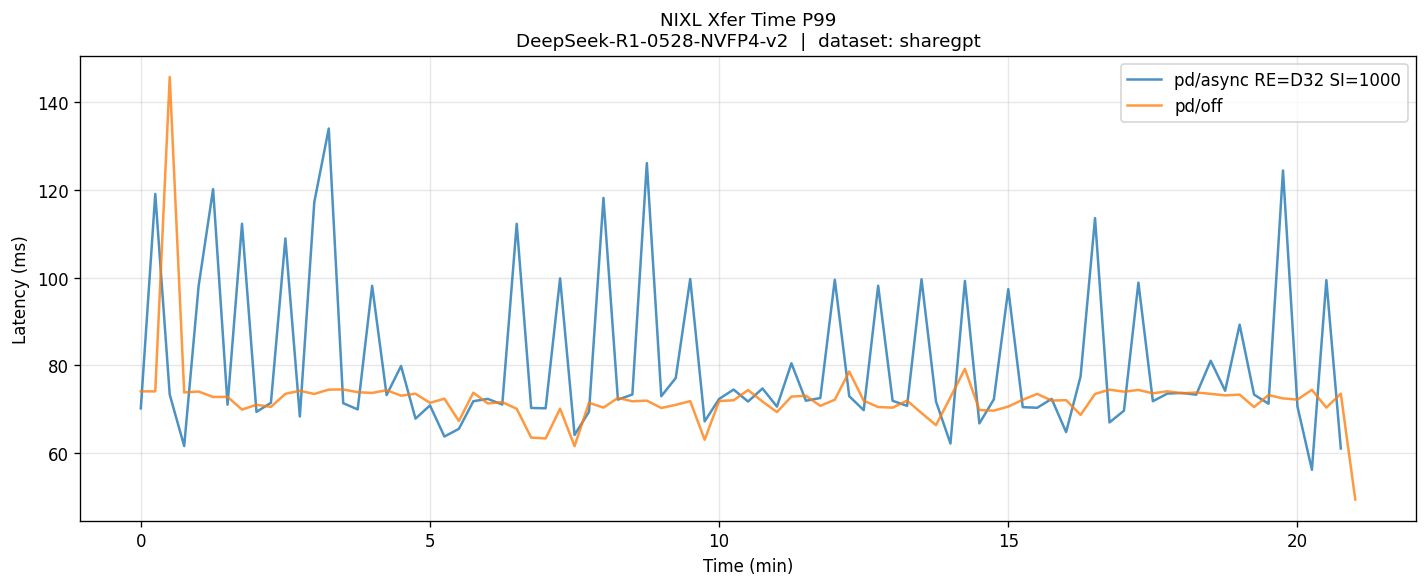

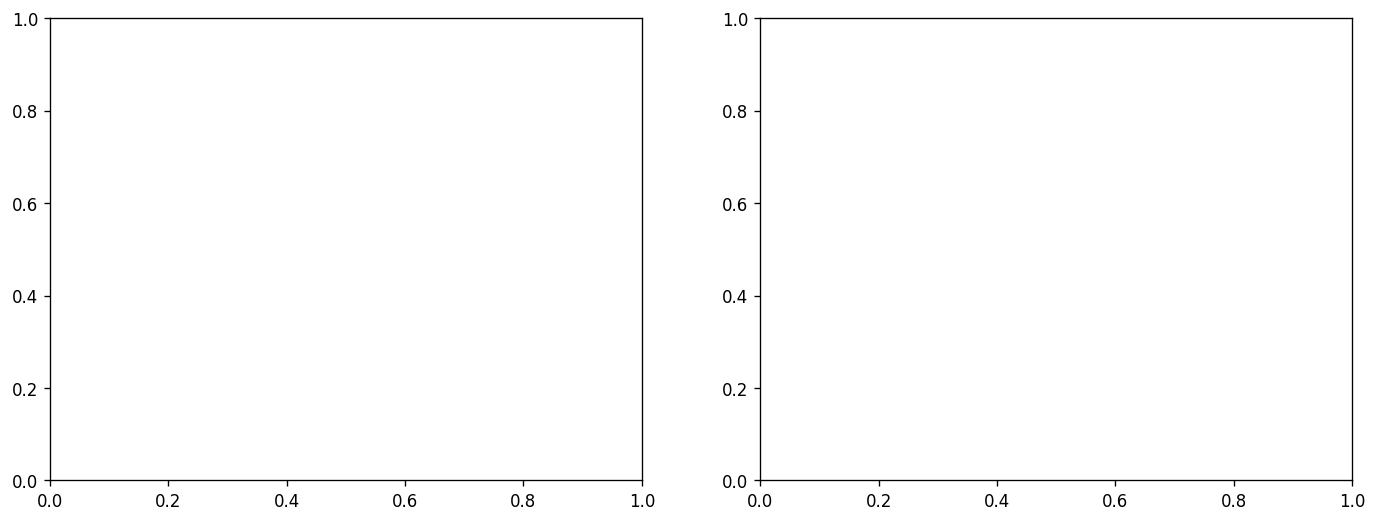

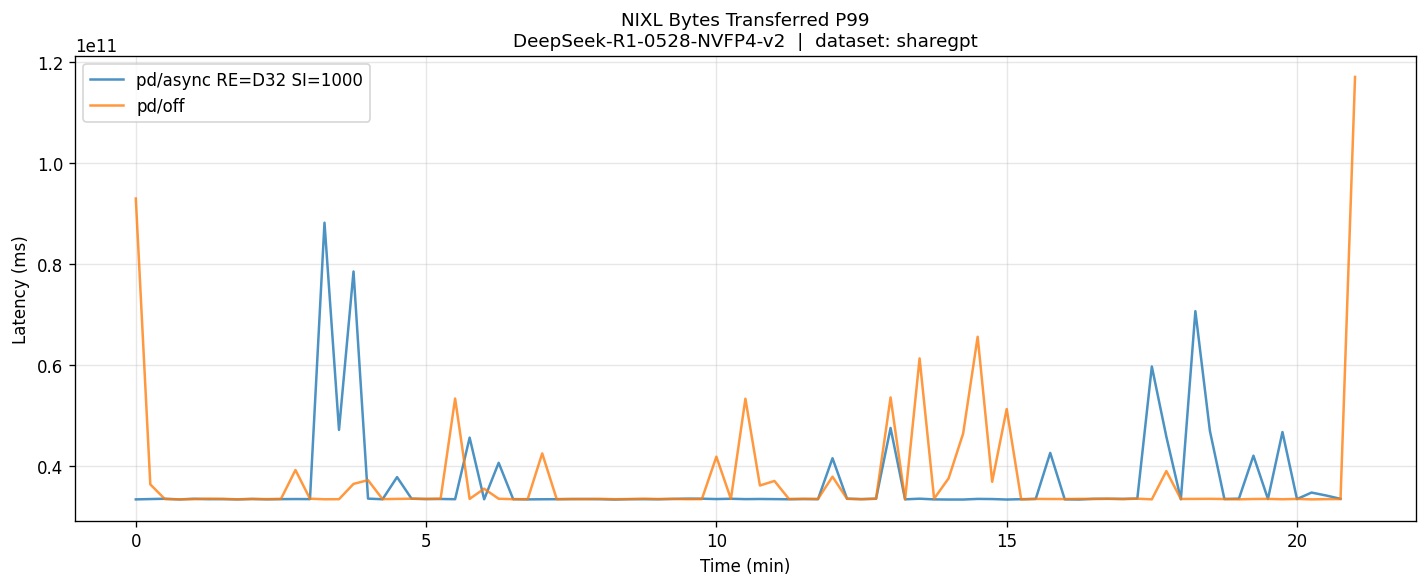

In [55]:
# NIXL transfer latency + decode local compute analysis
# nixl_xfer = total KV transfer time, nixl_post_time = submission time
# prompt_tokens_local_compute = tokens that decode had to prefill locally (no KV from prefill)
# prefill_kv_computed = tokens computed fresh per request (excludes cache hits)

# Per-stage NIXL xfer latency + decode local compute table
nixl_keys = ["nixl_xfer_p50", "nixl_xfer_p99", "nixl_post_time_p50", "nixl_post_time_p99",
             "nixl_bytes_p50", "nixl_bytes_p99", "nixl_descriptors_p50", "nixl_descriptors_p99",
             "nixl_failed_transfers_rate", "nixl_kv_expired_rate"]
compute_keys = ["decode_prompt_tokens_local_compute_rate", "decode_prompt_tokens_external_kv_transfer_rate",
                "decode_request_success_rate",
                "prefill_kv_computed_p50", "prefill_kv_computed_p99"]
time_keys = {"nixl_xfer_p50", "nixl_xfer_p99", "nixl_post_time_p50", "nixl_post_time_p99"}

if prom.n_stages > 0:
    rows = []
    for stage_meta in prom.get_stages():
        idx = stage_meta["stage"]
        row = {"stage": idx, "concurrency": stage_meta["concurrency"]}
        for key in nixl_keys + compute_keys:
            v = prom.stage_instant(idx, key)
            if v is not None:
                row[f"{key}_ms" if key in time_keys else key] = v * 1000 if key in time_keys else v
        rows.append(row)
    nixl_df = pd.DataFrame(rows).set_index("stage")
    if len(nixl_df.columns) > 1:
        print("NIXL transfer + decode local compute metrics per stage:")
        display(nixl_df)

        # Stage-over-stage deltas for NIXL xfer time
        xfer_cols = [c for c in nixl_df.columns if "nixl_xfer" in c]
        if xfer_cols:
            deltas = nixl_df[xfer_cols].diff()
            deltas.insert(0, "concurrency", nixl_df["concurrency"])
            print("\nNIXL xfer latency deltas (ms):")
            display(deltas.iloc[1:])

        # Decode local compute (decode-only pods, same as Grafana "Decode Local Prompt Tokens / Request")
        lc = "decode_prompt_tokens_local_compute_rate"
        ext = "decode_prompt_tokens_external_kv_transfer_rate"
        rps = "decode_request_success_rate"
        if lc in nixl_df.columns and ext in nixl_df.columns:
            total = nixl_df[lc] + nixl_df[ext]
            ratio = (nixl_df[lc] / total.replace(0, np.nan) * 100)
            compute_df = pd.DataFrame({
                "concurrency": nixl_df["concurrency"],
                "local_compute_tok/s": nixl_df[lc],
                "external_kv_tok/s": nixl_df[ext],
                "local_compute_%": ratio,
            })
            if rps in nixl_df.columns:
                req_rate = nixl_df[rps].replace(0, np.nan)
                compute_df["local_compute_tok/req"] = nixl_df[lc] / req_rate
                compute_df["external_kv_tok/req"] = nixl_df[ext] / req_rate
            print("\nDecode local compute (decode pods only):")
            display(compute_df)

# NIXL xfer time series (p99)
if "nixl_xfer_time_p99_range" in prom.raw:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.sca(axes[0])
    plot_latency_timeseries(runs, metric_key="nixl_xfer_time_p99_range", title="NIXL Xfer Time P99")
    plt.sca(axes[1])
    plot_latency_timeseries(runs, metric_key="nixl_bytes_p99_range", title="NIXL Bytes Transferred P99")
    plt.tight_layout()

### Prefill Per-Rank Analysis

Per-rank breakdown of prefill pod metrics to identify imbalance or stragglers.

Prefill per-rank: peak stage 3 vs worst stage 1


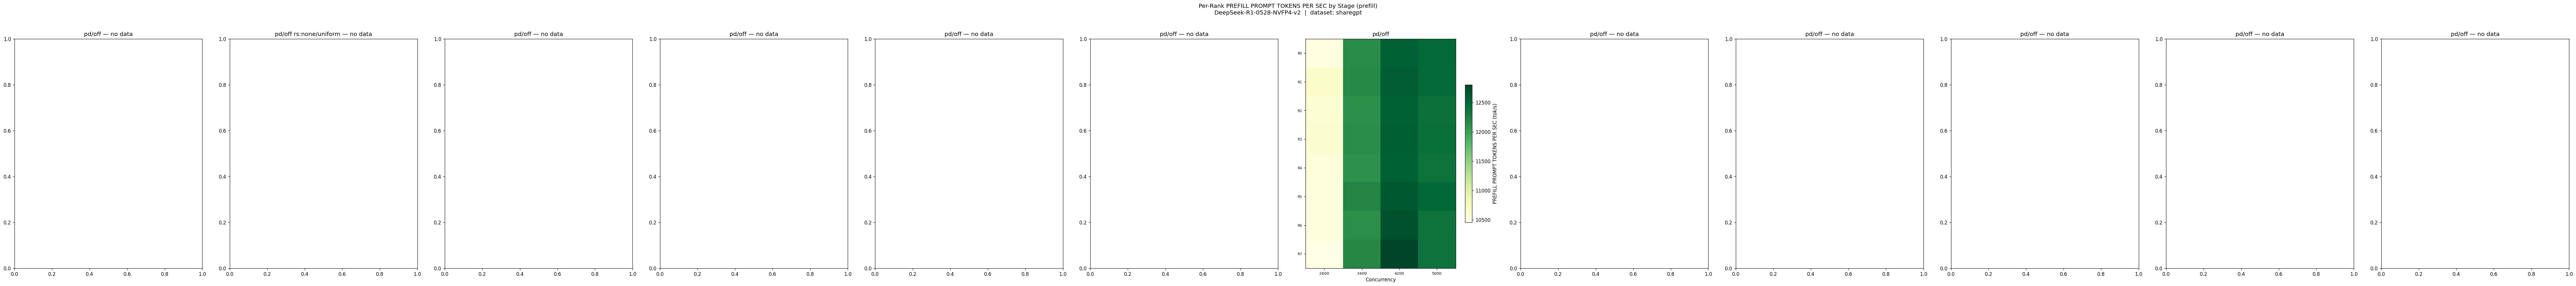

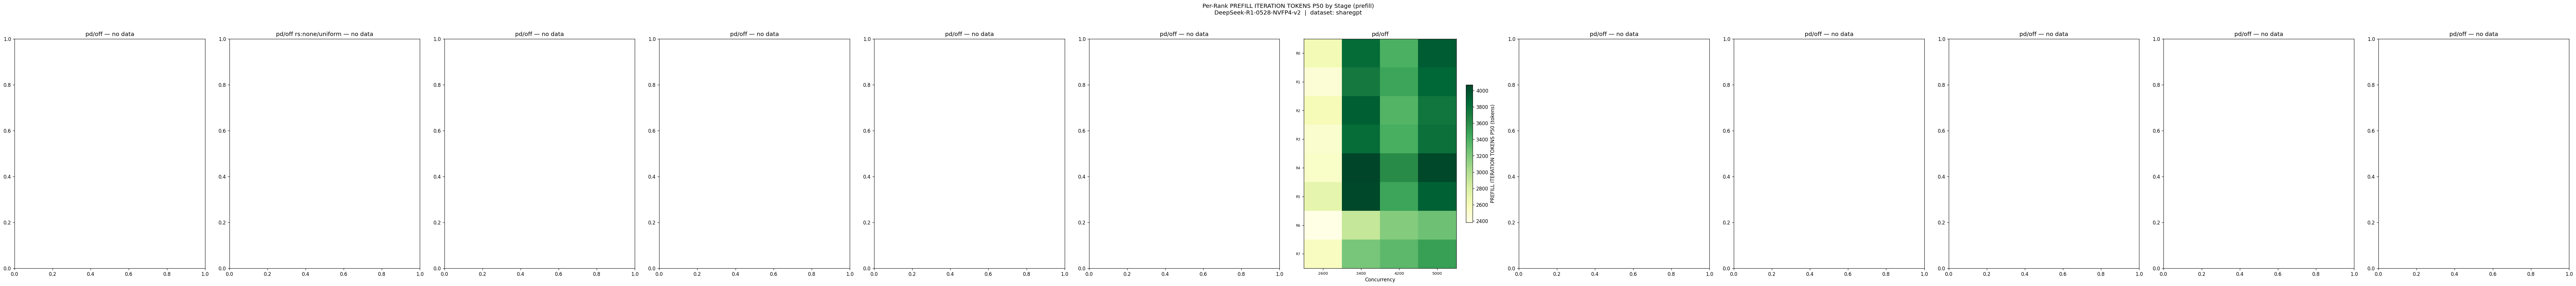

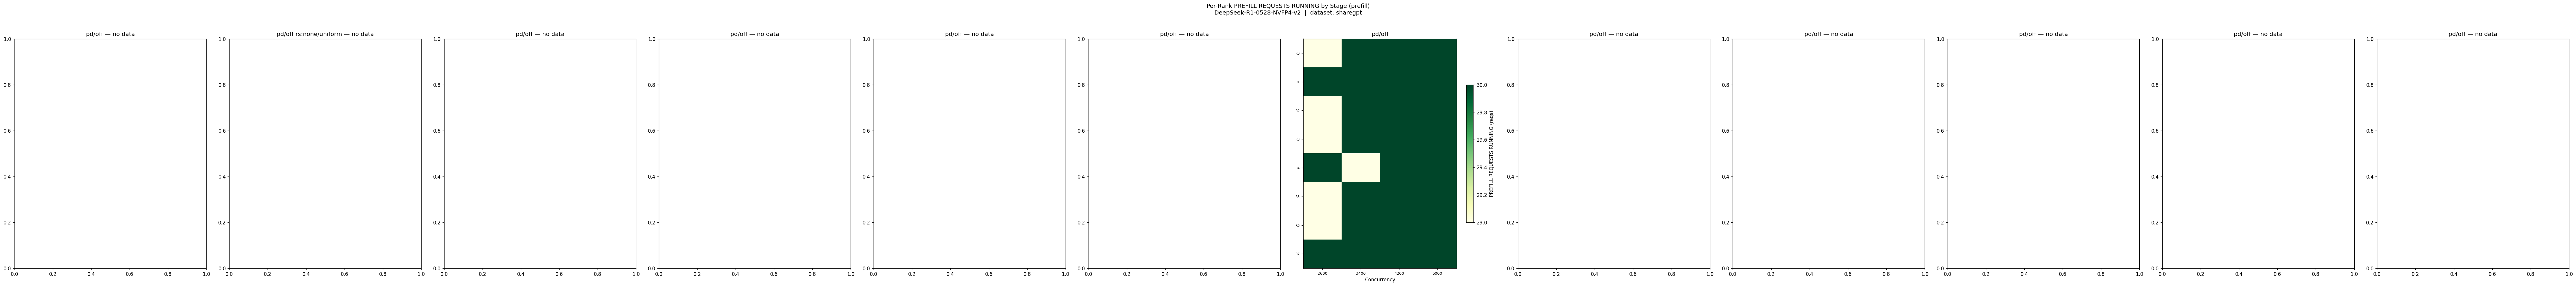

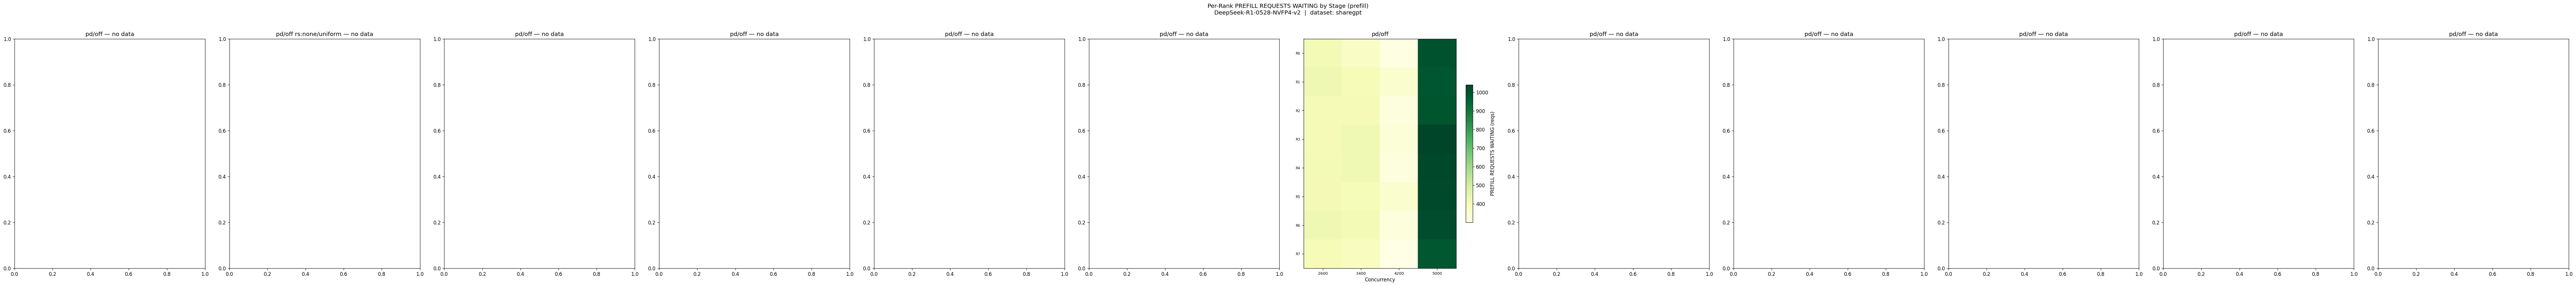

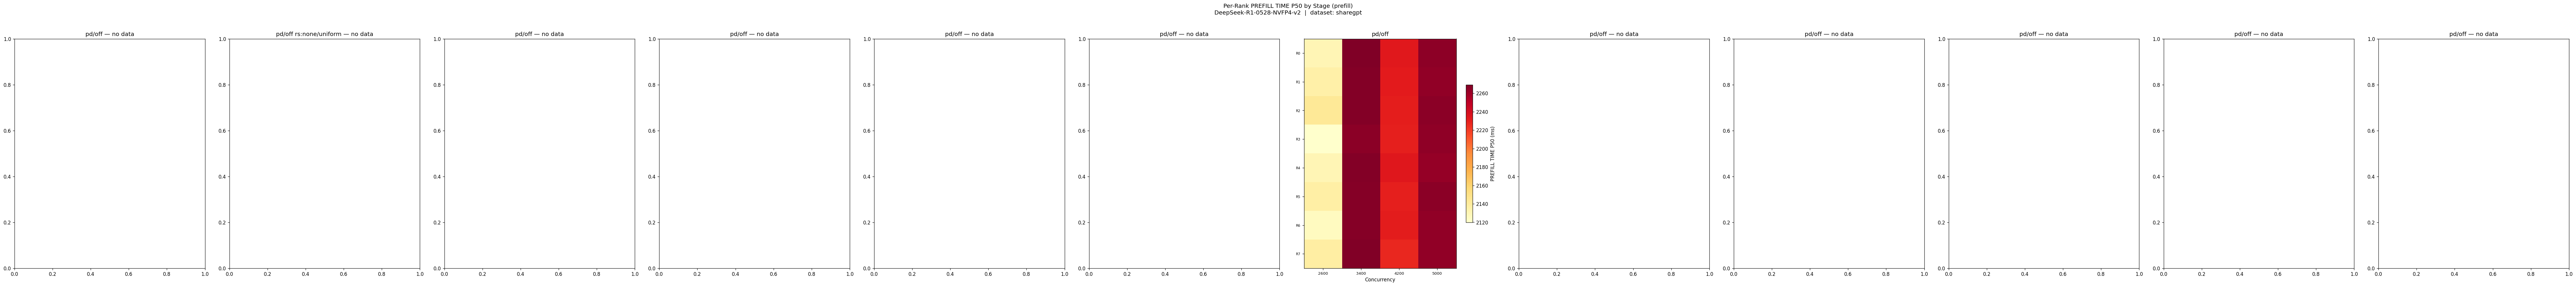

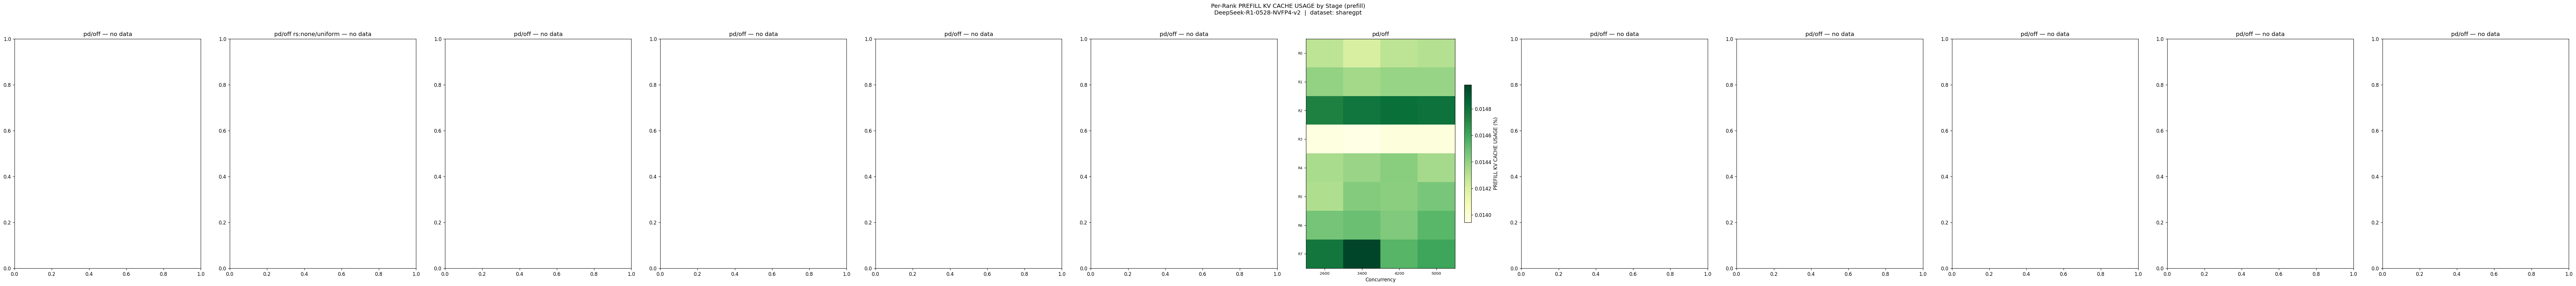

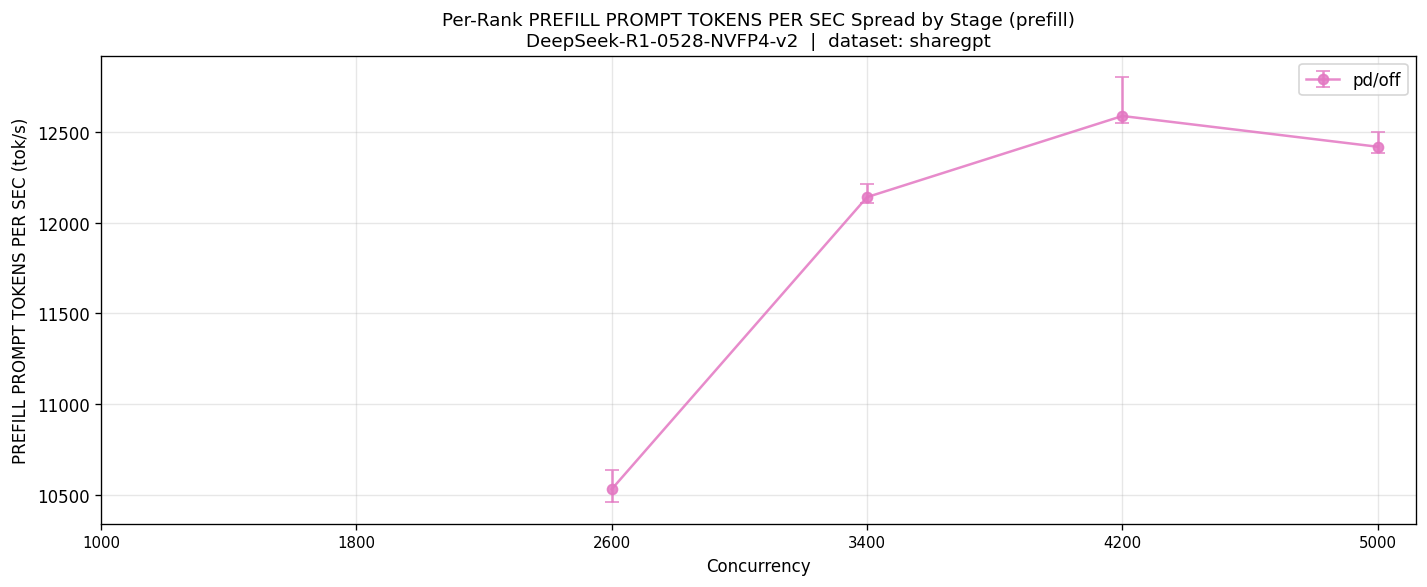

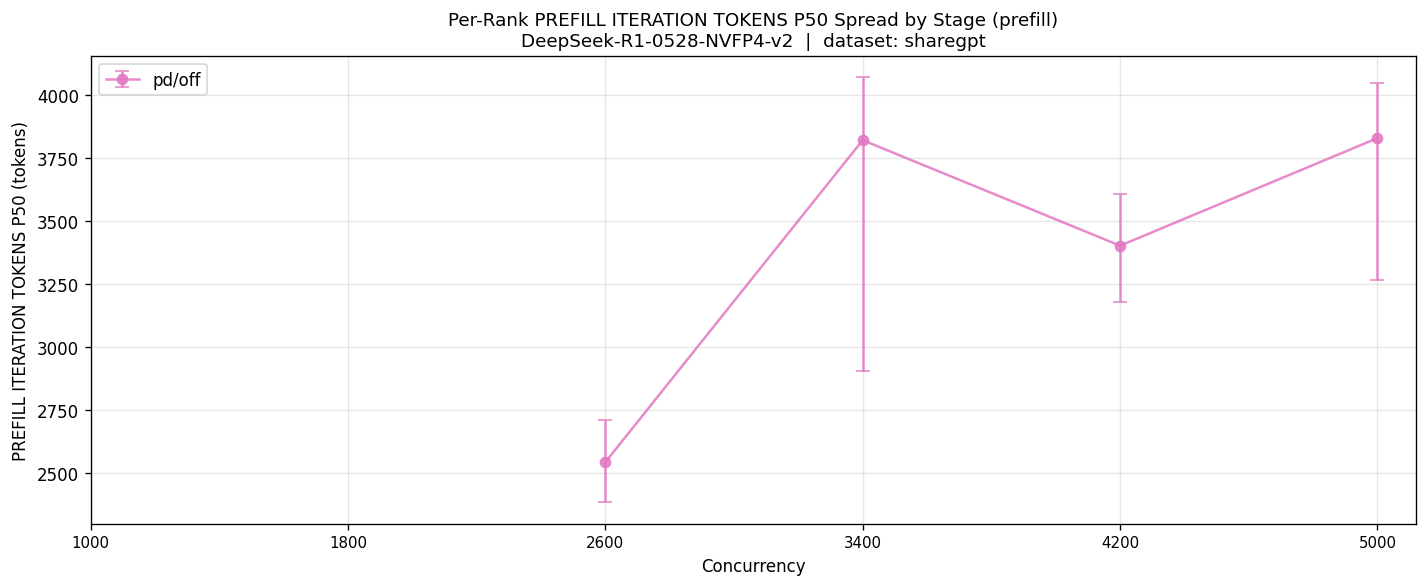

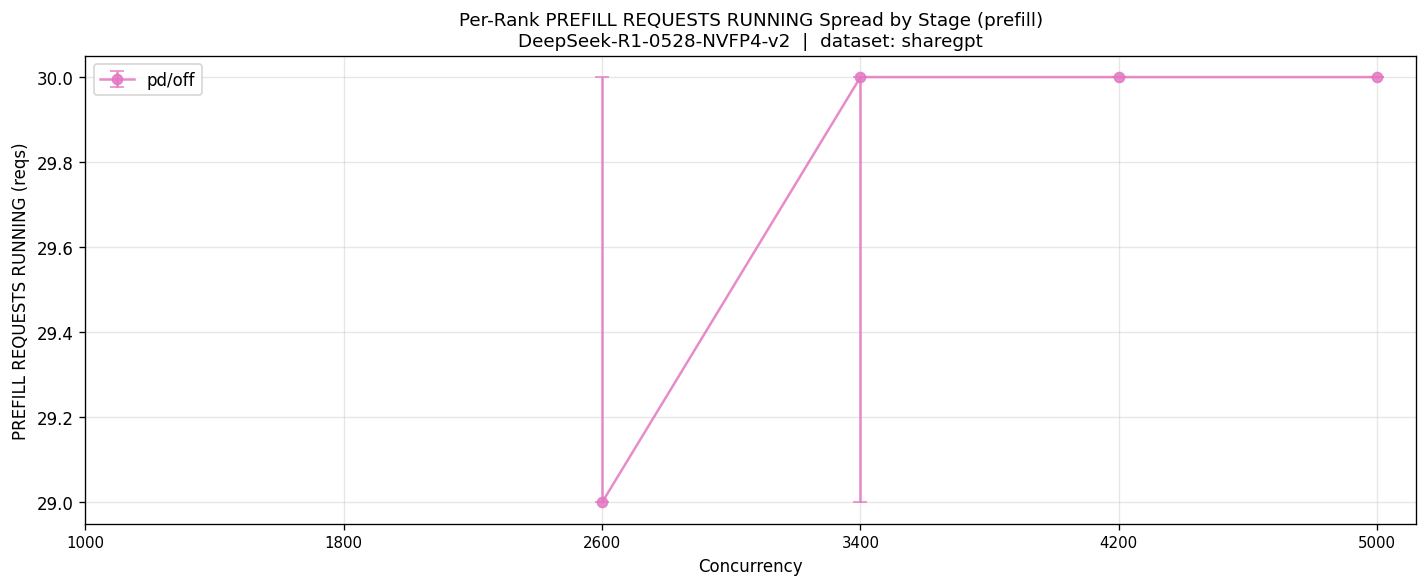

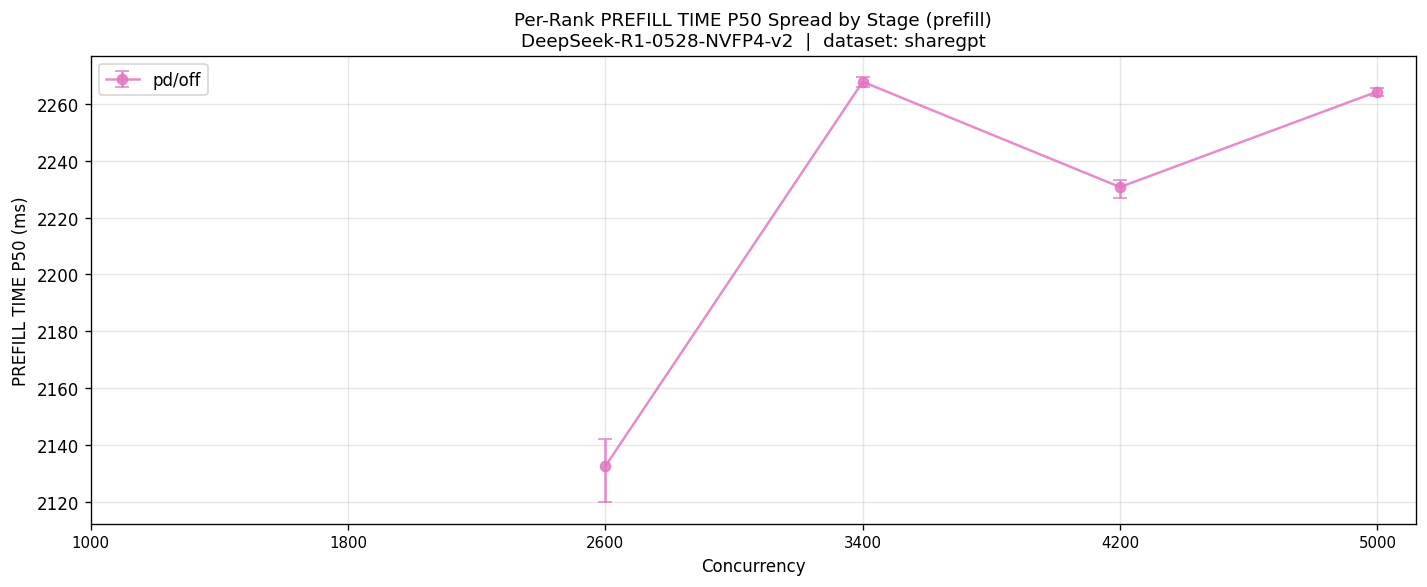

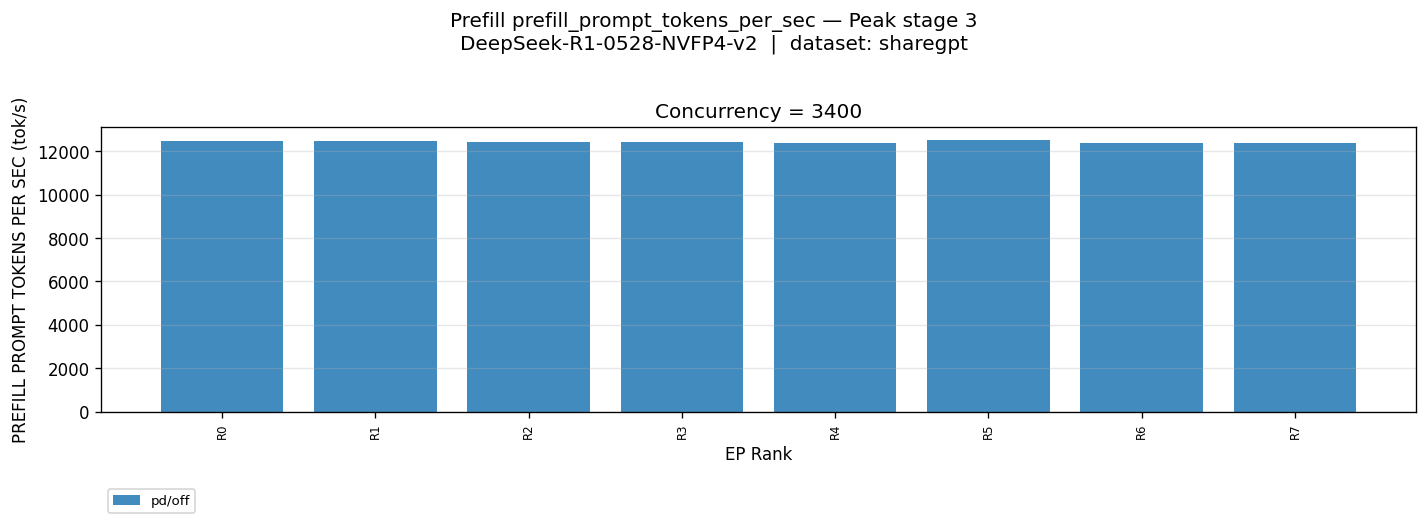

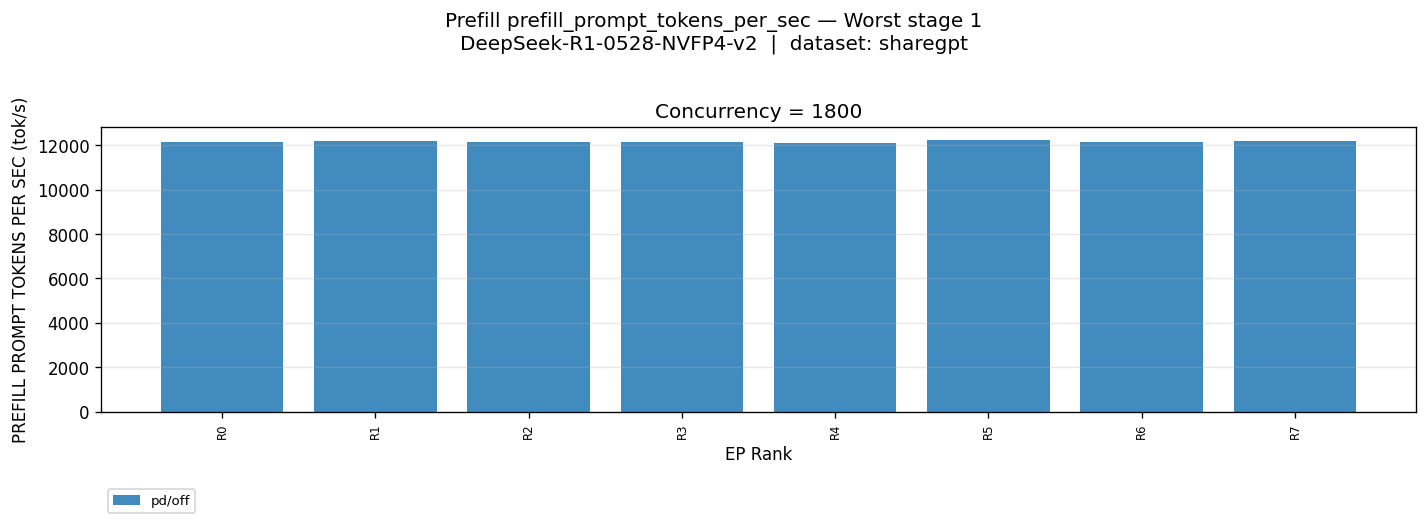

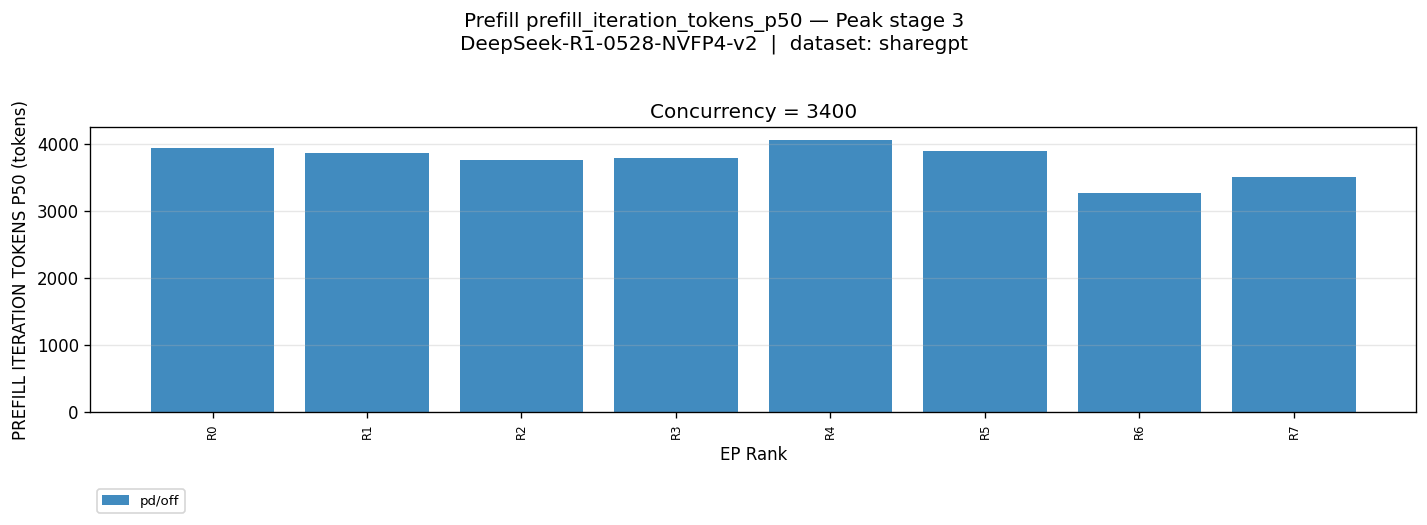

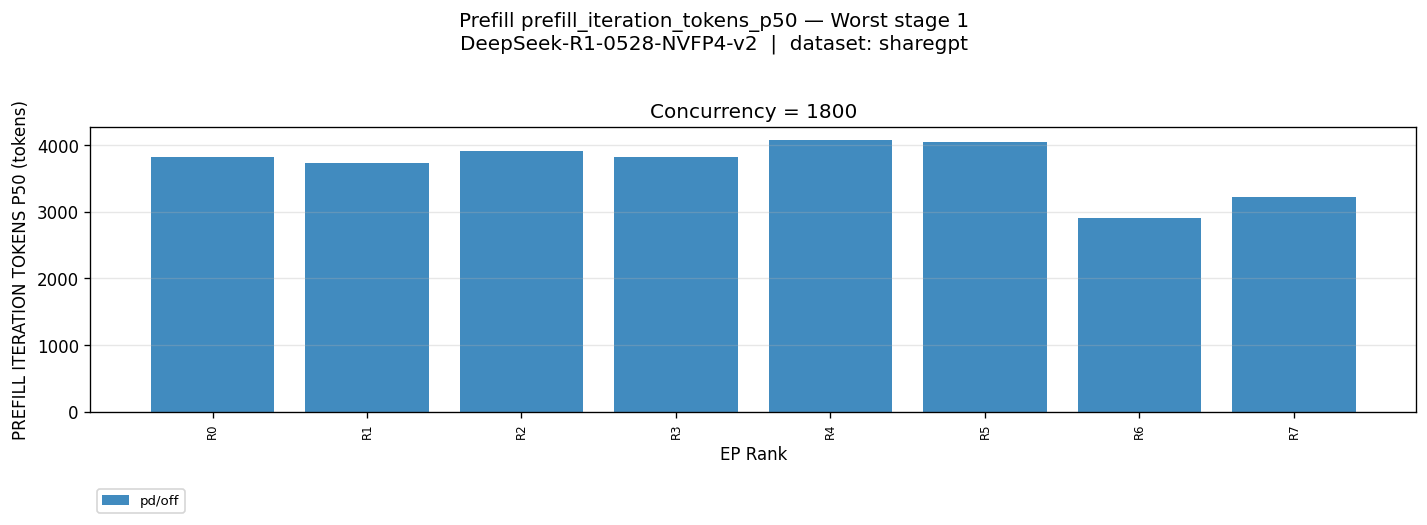

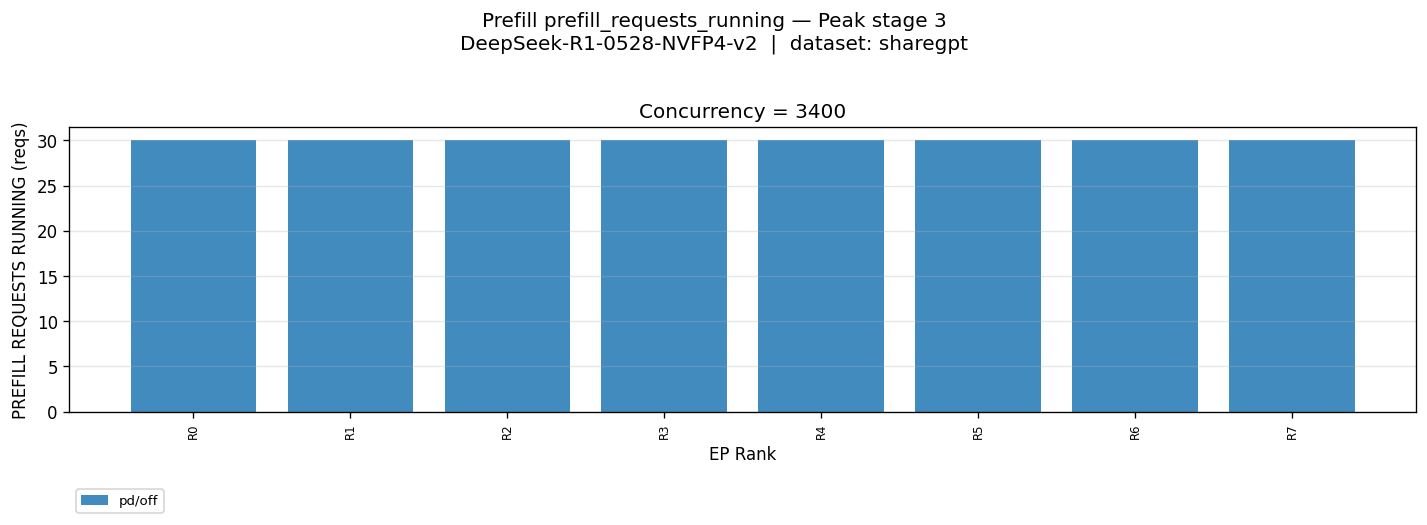

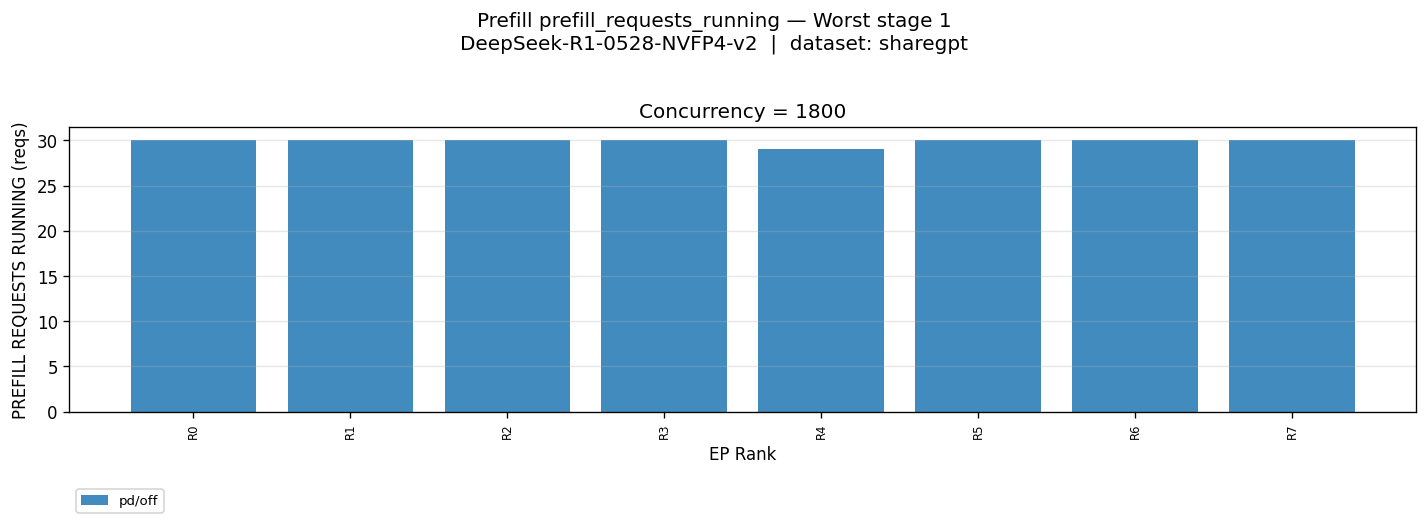

In [21]:
# Prefill per-rank heatmaps
prefill_metrics = [
    "prefill_prompt_tokens_per_sec",
    "prefill_iteration_tokens_p50",
    "prefill_requests_running",
    "prefill_requests_waiting",
    "prefill_time_p50",
    "prefill_kv_cache_usage",
]

for m in prefill_metrics:
    try:
        plot_per_rank_latency_heatmap(runs, metric=m, role="prefill")
    except Exception as e:
        print(f"Skipping heatmap {m}: {e}")

# Prefill per-rank spread (min/median/max across ranks per stage)
for m in ["prefill_prompt_tokens_per_sec", "prefill_iteration_tokens_p50",
          "prefill_requests_running", "prefill_time_p50"]:
    try:
        plot_per_rank_latency_spread(runs, metric=m, role="prefill")
    except Exception as e:
        print(f"Skipping spread {m}: {e}")

# Prefill per-rank comparison: peak vs worst stage
if smt is not None and "gen_tokens_per_sec" in smt.columns:
    peak = int(smt["gen_tokens_per_sec"].idxmax())
    worst = int(smt["gen_tokens_per_sec"].idxmin())
    print(f"Prefill per-rank: peak stage {peak} vs worst stage {worst}")
    for m in ["prefill_prompt_tokens_per_sec", "prefill_iteration_tokens_p50",
              "prefill_requests_running"]:
        try:
            plot_per_rank_comparison(runs, metric=m, role="prefill", stage=peak,
                                    title=f"Prefill {m} — Peak stage {peak}")
            plot_per_rank_comparison(runs, metric=m, role="prefill", stage=worst,
                                    title=f"Prefill {m} — Worst stage {worst}")
        except Exception as e:
            print(f"Skipping comparison {m}: {e}")

## 6. Findings + Next Steps

### Observable patterns -> likely cause -> next step

| Pattern | Likely Cause | Next Step |
|---------|-------------|----------|
| decode_time grows, spread flat | MNNVL saturation or compute scaling at 1024 tok/step | Profile with torch/nsys to decompose forward pass |
| decode_time grows, spread widens | Rank-specific bottleneck | Check NVSwitch topology, thermal, NIXL pod placement |
| decode_time flat, ITL grows | Scheduling/sidecar overhead | Profile vLLM scheduler, test without routing sidecars |
| queue_time grows | Scheduler can't keep up | Investigate `--async-scheduling` at high concurrency |
| NIXL xfer grows | Prefill-to-decode KV transfer bottleneck | Add prefill capacity or investigate IB utilization |
| requests_running hits 1024 | Batch size cap reached, admission-limited | Consider raising `MAX_TOKENS` |

### Profiling recommendations (if decode_time is the dominant grower)

1. `just profile` with `PROFILER_TYPE=torch` at high concurrency stage
2. Compare MNNVL dispatch/combine time vs expert compute time vs attention time
3. This definitively separates NVSwitch saturation from compute scaling

### Configuration experiments to try

| Change | Rationale |
|--------|----------|
| `VLLM_COMPUTE_NANS_IN_LOGITS=0` | Remove NaN scan overhead on every step |
| `--enable-dbo` on decode | Overlap DeepEP LL communication with compute via dual-batch |
| `--gpu-memory-utilization 0.80-0.85` on decode | Allow more concurrent sequences before queueing |
| Remove `UCX_TLS=^cuda_ipc` on decode | May allow NIXL to use NVSwitch instead of IB on NVL72 |
| `VLLM_FLASHINFER_MOE_BACKEND=latency` or `throughput` | Test alternatives to `masked_gemm` at high batch sizes |